# ASR Tutorial Remake with SLR80 Dataset

## Original
- **Prepared by:** Ye Kyaw Thu, Language Understanding Lab., Myanmar
- **Last Updated Date:** 20 June 2026
- **Reason:** *For AI Engineering (Fundamental) class students*

## Remake
This remake recreates the exact tutorial with a capped sample of 2,000 data points.

## Setup

In [1]:
from pathlib import Path

current_dir = Path.cwd()
SCRIPTS = current_dir / "scripts"
SRC = current_dir / "src"

## Download Dataset: SLR80

In [2]:
!time {SCRIPTS}/download_dataset.sh

--2026-09-21 16:54:21--  https://www.openslr.org/resources/80/line_index_female.tsv
Resolving www.openslr.org (www.openslr.org)... 136.243.171.4
Connecting to www.openslr.org (www.openslr.org)|136.243.171.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 541101 (528K) [text/tab-separated-values]
Saving to: ‘line_index_female.tsv’

line_index_female.t 100%[===================>] 528.42K  55.2KB/s    in 7.7s    

2026-09-21 16:54:30 (68.4 KB/s) - ‘line_index_female.tsv’ saved [541101/541101]

--2026-09-21 16:54:30--  https://www.openslr.org/resources/80/my_mm_female.zip
Resolving www.openslr.org (www.openslr.org)... 136.243.171.4
Connecting to www.openslr.org (www.openslr.org)|136.243.171.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 948181015 (904M) [application/zip]
Saving to: ‘my_mm_female.zip’

my_mm_female.zip    100%[===================>] 904.26M  86.0KB/s    in 4h 2m   

2026-09-21 20:56:43 (63.7 KB/s) - ‘my_mm_female.zip’ sav

In [3]:
!tree ./data/ | head -n 10

./data/
└── slr80
    ├── bur_0366_0045318711.wav
    ├── bur_0366_0096392289.wav
    ├── bur_0366_0178258874.wav
    ├── bur_0366_0235517782.wav
    ├── bur_0366_0432235369.wav
    ├── bur_0366_0445549145.wav
    ├── bur_0366_0446483510.wav
    ├── bur_0366_0469985799.wav


In [4]:
!head ./data/slr80/line_index_female.tsv

bur_7865_1250917969	ပြီးတော့ တရုတ် နဲ့လည်း ချစ်ကြည်ရင်းနှီးတဲ့ ဆက်ဆံရေး ရှိတယ်
bur_8698_6883351313	အဲ့ဒီ ဝေဖန်မှုတွေ နဲ့ ပတ်သက် လို့ ဘယ်လို တုံ့ပြန်ချင်ပါသလဲ
bur_3260_8853590661	မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်
bur_2446_1980151079	ခင်ဦးသာ နှင့် နန်းလွင်နှင်းပွင့် ပူးပေါင်း ရေးသားသည်
bur_5189_8958061789	ကြည့်ရသည်မှာ မြန်မာ နိုင်ငံ တွင် သူ့ အတွက် ခိုလှုံရာ တခု တွေ့ခဲ့ပုံ ရပါသည်
bur_6884_6350507293	မမဖွေးဖွေး နဲ့ တွေ့ရ တော့ တအား ပျော်တယ် လို့ ပြောပါတယ်
bur_5362_7563127136	အထူးသဖြင့် နိုင်ငံရေး လောက ကို စုစည်းနိုင်ခဲ့သည် ဟု ဆိုနိုင်ပါသည်
bur_7543_6156096513	ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ
bur_8266_0671510151	ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး
bur_6118_8081481703	ကျွန်မ အလုပ် ကို လေးလေးစားစား လုပ်ပါတယ်


In [5]:
!head ./data/slr80/line_index.tsv

bur_7865_1250917969	ပြီးတော့ တရုတ် နဲ့လည်း ချစ်ကြည်ရင်းနှီးတဲ့ ဆက်ဆံရေး ရှိတယ်
bur_8698_6883351313	အဲ့ဒီ ဝေဖန်မှုတွေ နဲ့ ပတ်သက် လို့ ဘယ်လို တုံ့ပြန်ချင်ပါသလဲ
bur_3260_8853590661	မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်
bur_2446_1980151079	ခင်ဦးသာ နှင့် နန်းလွင်နှင်းပွင့် ပူးပေါင်း ရေးသားသည်
bur_5189_8958061789	ကြည့်ရသည်မှာ မြန်မာ နိုင်ငံ တွင် သူ့ အတွက် ခိုလှုံရာ တခု တွေ့ခဲ့ပုံ ရပါသည်
bur_6884_6350507293	မမဖွေးဖွေး နဲ့ တွေ့ရ တော့ တအား ပျော်တယ် လို့ ပြောပါတယ်
bur_5362_7563127136	အထူးသဖြင့် နိုင်ငံရေး လောက ကို စုစည်းနိုင်ခဲ့သည် ဟု ဆိုနိုင်ပါသည်
bur_7543_6156096513	ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ
bur_8266_0671510151	ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး
bur_6118_8081481703	ကျွန်မ အလုပ် ကို လေးလေးစားစား လုပ်ပါတယ်


## Prepare Dataset: SLR80

In [6]:
!time python {SRC}/myanmar_asr.py --stage prep \
  --data_dir  ./data/slr80 \
  --output_dir ./asr_output \
  --train_ratio 0.80 \
  --dev_ratio   0.10 \
  --max_samples 2000

2026-09-21 22:25:49  [INFO    ]  Myanmar ASR Tutorial  —  SLR80 Burmese Speech Corpus
2026-09-21 22:25:49  [INFO    ]  Stage: prep   Seed: 42
2026-09-21 22:25:51  [INFO    ]  ── Stage: Data Preparation ─────────────────────────────
2026-09-21 22:25:51  [INFO    ]  Audio found flat in: data/slr80/  (2530 wav files)
2026-09-21 22:25:51  [INFO    ]  TSV parse: 2530 valid rows  (0 missing audio,  0 malformed lines)
2026-09-21 22:25:51  [INFO    ]    Capped at 2000 samples (--max_samples)
2026-09-21 22:25:51  [INFO    ]    train:  1600 utterances  →  asr_output/train.json
2026-09-21 22:25:51  [INFO    ]    dev  :   200 utterances  →  asr_output/dev.json
2026-09-21 22:25:51  [INFO    ]    test :   200 utterances  →  asr_output/test.json
2026-09-21 22:25:51  [INFO    ]  Character vocab: 63 tokens  →  asr_output/myanmar_vocab.json
  ([PAD]=0, [UNK]=1, |=word-boundary, +60 unique chars)
2026-09-21 22:25:51  [INFO    ]  Data preparation complete.
2026-09-21 22:25:51  [INFO    ]  All stages compl

In [7]:
!tree ./asr_output

./asr_output
├── checkpoints
├── dev.json
├── myanmar_processor
│   ├── added_tokens.json
│   ├── processor_config.json
│   ├── tokenizer_config.json
│   └── vocab.json
├── myanmar_vocab.json
├── test.json
└── train.json

3 directories, 8 files


In [8]:
!wc ./asr_output/*.json

  1001   3221  60069 ./asr_output/dev.json
    64    128    813 ./asr_output/myanmar_vocab.json
  1001   3148  58719 ./asr_output/test.json
  8001  25392 478523 ./asr_output/train.json
 10067  31889 598124 total


### Training Data

In [9]:
!head -n 26 ./asr_output/train.json 

[
  {
    "id": "bur_3260_6745062637",
    "wav": "data/slr80/bur_3260_6745062637.wav",
    "text": "မော်ဒန်ပန်းချီ ကို ဦးဆောင်ခဲ့သည့် ပထမ မျိုးဆက် မှာ ဦးခင်မောင် ဗဂျီအောင်စိုးတို့ ဖြစ်သည်"
  },
  {
    "id": "bur_9135_1937071666",
    "wav": "data/slr80/bur_9135_1937071666.wav",
    "text": "ဒေါ်အောင်ဆန်းစုကြည် ဟာ မနက်ဖြန် ကျိုင်းတုံ မြို့ ကို သွားရောက်ပါလိမ့်မယ်"
  },
  {
    "id": "bur_2446_1649884503",
    "wav": "data/slr80/bur_2446_1649884503.wav",
    "text": "ဒါကြီး မပြင်ဘဲ ဘယ်လို လုပ် ဒေါ်စု သမ္မတ ဖြစ်မှာလဲ"
  },
  {
    "id": "bur_9762_7608593333",
    "wav": "data/slr80/bur_9762_7608593333.wav",
    "text": "ဗြိတိန် နိုင်ငံ မှာ တရားစီရင်တာ အဲဒီလို မဟုတ်ဘူး"
  },
  {
    "id": "bur_4632_0384667016",
    "wav": "data/slr80/bur_4632_0384667016.wav",
    "text": "အမျိုးသား ပြည့်တန်ဆာ ကြတော့ အသွင်ယူ ပြီး ဖမ်းလို့ မရဘူး"
  },


### Validation Data

In [10]:
!head -n 26 ./asr_output/dev.json

[
  {
    "id": "bur_7712_9168792651",
    "wav": "data/slr80/bur_7712_9168792651.wav",
    "text": "ရဲ နဲ့ ခေါ်လာ တော့မှ ဆေးရုံ ကို လိုက်လာတာ"
  },
  {
    "id": "bur_9135_6623645627",
    "wav": "data/slr80/bur_9135_6623645627.wav",
    "text": "အဲ့ဒါကြောင့် ကျွန်တော် လည်း သွားဖို့ သင်တန်းတွေ တက် စာမေးပွဲတွေ ဖြေတယ်"
  },
  {
    "id": "bur_5189_6705887485",
    "wav": "data/slr80/bur_5189_6705887485.wav",
    "text": "ကျနော် လည်း လမ်းလျှောက်တဲ့ အထဲမှာ ပါပါတယ်"
  },
  {
    "id": "bur_6118_4380049117",
    "wav": "data/slr80/bur_6118_4380049117.wav",
    "text": "ဘုရားပွဲ ကျောင်းပွဲ တွေ ရှိရင် မြန်မာ့ သဘင် ဟာ မဖြစ်မနေ ရှိနေမှာ ဖြစ်ပါတယ်"
  },
  {
    "id": "bur_5932_2036572668",
    "wav": "data/slr80/bur_5932_2036572668.wav",
    "text": "အစ်မတို့ အနေနဲ့ လည်း တအား ဝမ်းသာမိတယ်"
  },


### Test Data

In [11]:
!head -n 26 ./asr_output/test.json

[
  {
    "id": "bur_4409_5149640508",
    "wav": "data/slr80/bur_4409_5149640508.wav",
    "text": "နိုင်ငံရေး ဆောင်ရွက်သူ သည် နိုင်ငံရေးသမား ဖြစ်သည်"
  },
  {
    "id": "bur_7712_3637049235",
    "wav": "data/slr80/bur_7712_3637049235.wav",
    "text": "တိုး ပြီး လာနေကြသည့် ကမ္ဘာလှည့် ခရီးသွားတွေ အတွက် လည်း ဟိုတယ်ခန်းတွေ လိုနေသည်"
  },
  {
    "id": "bur_0644_0082344273",
    "wav": "data/slr80/bur_0644_0082344273.wav",
    "text": "ဒီလို သင်္ကြန်ပွဲတော် ဆိုတာ လည်း ကျမတို့ မြန်မာ တနိုင်ငံတည်း ရှိတာလေ"
  },
  {
    "id": "bur_4632_7445233074",
    "wav": "data/slr80/bur_4632_7445233074.wav",
    "text": "ဒီ ဥပဒေ ဟာ ဒီနေ့ အထိ တော့ ဖျက်သိမ်းတယ် ဆိုတာ မရှိသေးဘူး"
  },
  {
    "id": "bur_7865_0071910543",
    "wav": "data/slr80/bur_7865_0071910543.wav",
    "text": "သူ့ ကို ကြည့် ပြီး သနား လည်း သနားတယ် အားမငယ်အောင် ထားဖြစ်တယ်"
  },


### Vocab File

In [12]:
!cat ./asr_output/myanmar_vocab.json

{
  "[PAD]": 0,
  "[UNK]": 1,
  "|": 2,
  "က": 3,
  "ခ": 4,
  "ဂ": 5,
  "ဃ": 6,
  "င": 7,
  "စ": 8,
  "ဆ": 9,
  "ဇ": 10,
  "ဈ": 11,
  "ဉ": 12,
  "ည": 13,
  "ဋ": 14,
  "ဌ": 15,
  "ဍ": 16,
  "ဏ": 17,
  "တ": 18,
  "ထ": 19,
  "ဒ": 20,
  "ဓ": 21,
  "န": 22,
  "ပ": 23,
  "ဖ": 24,
  "ဗ": 25,
  "ဘ": 26,
  "မ": 27,
  "ယ": 28,
  "ရ": 29,
  "လ": 30,
  "ဝ": 31,
  "သ": 32,
  "ဟ": 33,
  "ဠ": 34,
  "အ": 35,
  "ဤ": 36,
  "ဥ": 37,
  "ဦ": 38,
  "ဧ": 39,
  "ဩ": 40,
  "ါ": 41,
  "ာ": 42,
  "ိ": 43,
  "ီ": 44,
  "ု": 45,
  "ူ": 46,
  "ေ": 47,
  "ဲ": 48,
  "ံ": 49,
  "့": 50,
  "း": 51,
  "္": 52,
  "်": 53,
  "ျ": 54,
  "ြ": 55,
  "ွ": 56,
  "ှ": 57,
  "ဿ": 58,
  "၌": 59,
  "၍": 60,
  "၎": 61,
  "၏": 62
}

## Model Training

In [13]:
!nvidia-smi

Mon Sep 21 22:25:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1060        Off |   00000000:01:00.0 Off |                  N/A |
| N/A   54C    P8             10W /   88W |       9MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
!time python {SRC}/myanmar_asr.py --stage train \
  --output_dir ./asr_output \
  --model_name facebook/wav2vec2-base \
  --epochs 20 \
  --lr 1e-4 \
  --batch_size 8 \
  --grad_accum 2 \
  --fp16 \
  --early_stop_patience 5

2026-09-21 22:25:59  [INFO    ]  Myanmar ASR Tutorial  —  SLR80 Burmese Speech Corpus
2026-09-21 22:25:59  [INFO    ]  Stage: train   Seed: 42
2026-09-21 22:26:00  [INFO    ]  ── Stage: Training ─────────────────────────────────────
2026-09-21 22:26:04  [INFO    ]  Train: 1600  Dev: 200
2026-09-21 22:26:05  [INFO    ]  HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-09-21 22:26:05  [INFO    ]  HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-09-21 22:26:05  [INFO    ]  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/preprocessor_config.json?%2Ffacebook%2Fwav2vec2-base%2Fresolve%2Fmain%2Fpreprocessor_config.json=&etag=%223f24dc078fcba55ee1d417a413847ead40c093a3%22 "HTTP/1.1 200 OK"
2026-09-21 22:26:05  [INFO    ]  Myanmar processor s

## Training Outputs

In [15]:
!tree ./asr_output/

./asr_output/
├── best_model
│   ├── added_tokens.json
│   ├── config.json
│   ├── model.safetensors
│   ├── preprocessor_config.json
│   ├── processor_config.json
│   ├── tokenizer_config.json
│   ├── training_args.bin
│   └── vocab.json
├── checkpoints
│   ├── checkpoint-1800
│   │   ├── config.json
│   │   ├── model.safetensors
│   │   ├── optimizer.pt
│   │   ├── preprocessor_config.json
│   │   ├── rng_state.pth
│   │   ├── scaler.pt
│   │   ├── scheduler.pt
│   │   ├── trainer_state.json
│   │   └── training_args.bin
│   ├── checkpoint-1900
│   │   ├── config.json
│   │   ├── model.safetensors
│   │   ├── optimizer.pt
│   │   ├── preprocessor_config.json
│   │   ├── rng_state.pth
│   │   ├── scaler.pt
│   │   ├── scheduler.pt
│   │   ├── trainer_state.json
│   │   └── training_args.bin
│   └── checkpoint-2000
│       ├── config.json
│       ├── model.safetensors
│       ├── optimizer.pt
│       ├── preprocessor_config.json
│       ├── rng_state.pth
│       ├── scaler.pt
│       ├

### Training Output: History

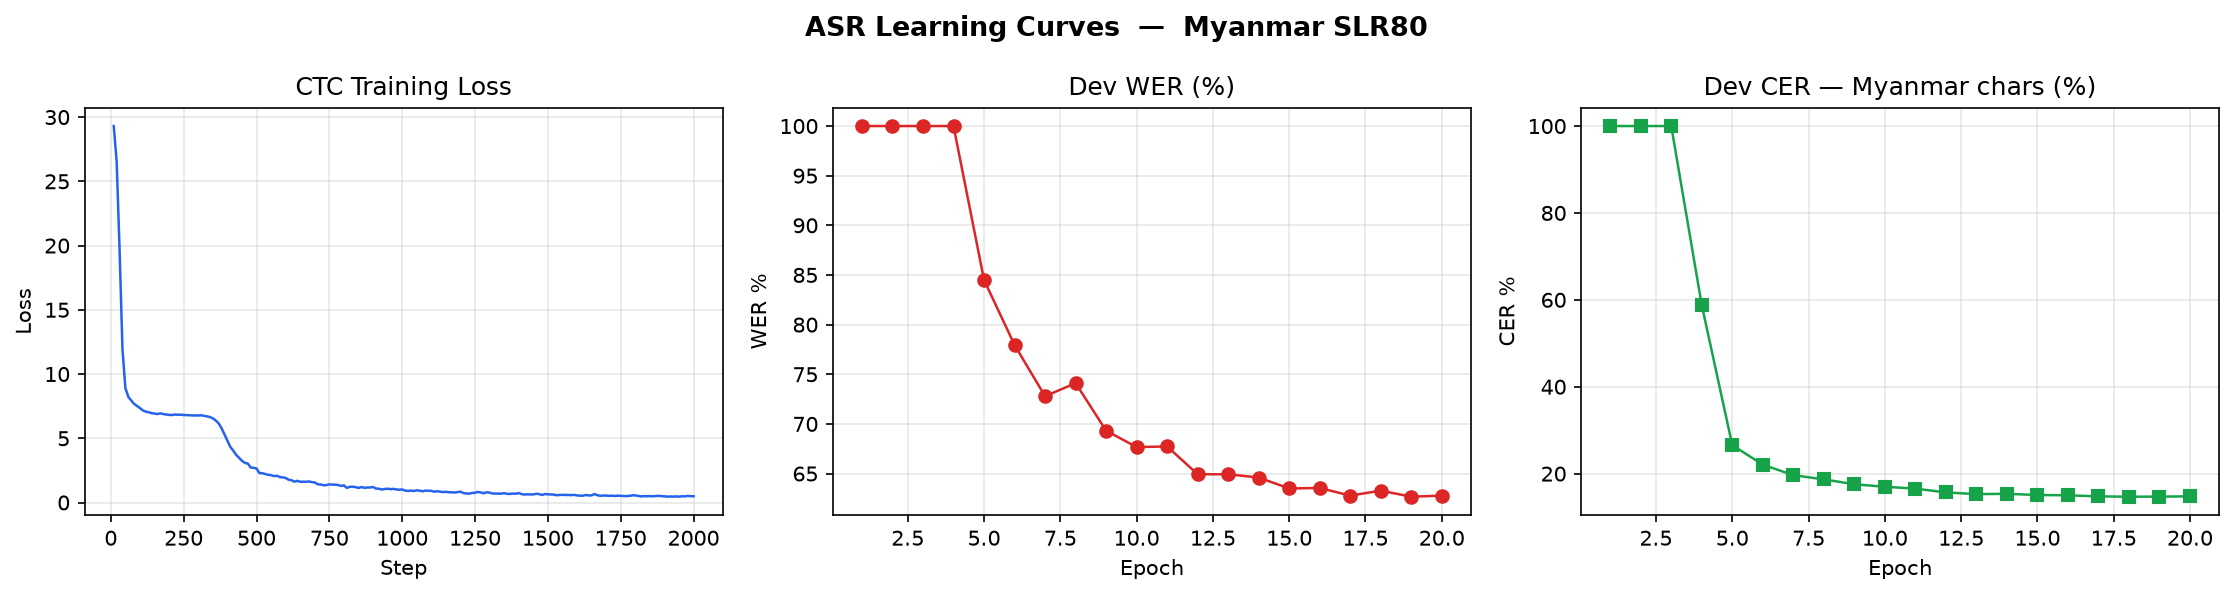

In [16]:
from IPython.display import Image

# Adjust size by setting the width (maintains aspect ratio if height is omitted)
Image(filename='./asr_output/learning_curve_asr.png', width=1200)

### Training Output: Config Files

In [17]:
!cat ./asr_output/best_model/config.json

{
  "activation_dropout": 0.0,
  "adapter_attn_dim": null,
  "adapter_kernel_size": 3,
  "adapter_stride": 2,
  "add_adapter": false,
  "apply_spec_augment": true,
  "architectures": [
    "Wav2Vec2ForCTC"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 1,
  "classifier_proj_size": 256,
  "codevector_dim": 256,
  "contrastive_logits_temperature": 0.1,
  "conv_bias": false,
  "conv_dim": [
    512,
    512,
    512,
    512,
    512,
    512,
    512
  ],
  "conv_kernel": [
    10,
    3,
    3,
    3,
    3,
    2,
    2
  ],
  "conv_stride": [
    5,
    2,
    2,
    2,
    2,
    2,
    2
  ],
  "ctc_loss_reduction": "mean",
  "ctc_zero_infinity": false,
  "diversity_loss_weight": 0.1,
  "do_stable_layer_norm": false,
  "dtype": "float32",
  "eos_token_id": 2,
  "feat_extract_activation": "gelu",
  "feat_extract_norm": "group",
  "feat_proj_dropout": 0.1,
  "feat_quantizer_dropout": 0.0,
  "final_dropout": 0.0,
  "freeze_feat_extract_train": true,
  "hidden_act": "gelu",
  "hidde

In [18]:
!cat ./asr_output/best_model/preprocessor_config.json

{
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}


In [19]:
!cat ./asr_output/best_model/tokenizer_config.json

{
  "added_tokens_decoder": {
    "0": {
      "content": "[PAD]",
      "lstrip": true,
      "normalized": false,
      "rstrip": true,
      "single_word": false,
      "special": false
    },
    "1": {
      "content": "[UNK]",
      "lstrip": true,
      "normalized": false,
      "rstrip": true,
      "single_word": false,
      "special": false
    },
    "2": {
      "content": "|",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    },
    "63": {
      "content": "<s>",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    },
    "64": {
      "content": "</s>",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    }
  },
  "backend": "custom",
  "bos_token": "<s>",
  "do_lower_case": false,
  "eos_token": "</s>",
  "model_max_length": 1000000000000000019884

In [20]:
!cat ./asr_output/best_model/added_tokens.json

{
  "</s>": 64,
  "<s>": 63
}


In [21]:
!cat ./asr_output/best_model/processor_config.json

{
  "feature_extractor": {
    "do_normalize": true,
    "feature_extractor_type": "Wav2Vec2FeatureExtractor",
    "feature_size": 1,
    "padding_side": "right",
    "padding_value": 0.0,
    "return_attention_mask": true,
    "sampling_rate": 16000
  },
  "processor_class": "Wav2Vec2Processor"
}


### Training Output: Vocab File of the Best Model

In [22]:
!cat ./asr_output/best_model/vocab.json

{
  "[PAD]": 0,
  "[UNK]": 1,
  "|": 2,
  "က": 3,
  "ခ": 4,
  "ဂ": 5,
  "ဃ": 6,
  "င": 7,
  "စ": 8,
  "ဆ": 9,
  "ဇ": 10,
  "ဈ": 11,
  "ဉ": 12,
  "ည": 13,
  "ဋ": 14,
  "ဌ": 15,
  "ဍ": 16,
  "ဏ": 17,
  "တ": 18,
  "ထ": 19,
  "ဒ": 20,
  "ဓ": 21,
  "န": 22,
  "ပ": 23,
  "ဖ": 24,
  "ဗ": 25,
  "ဘ": 26,
  "မ": 27,
  "ယ": 28,
  "ရ": 29,
  "လ": 30,
  "ဝ": 31,
  "သ": 32,
  "ဟ": 33,
  "ဠ": 34,
  "အ": 35,
  "ဤ": 36,
  "ဥ": 37,
  "ဦ": 38,
  "ဧ": 39,
  "ဩ": 40,
  "ါ": 41,
  "ာ": 42,
  "ိ": 43,
  "ီ": 44,
  "ု": 45,
  "ူ": 46,
  "ေ": 47,
  "ဲ": 48,
  "ံ": 49,
  "့": 50,
  "း": 51,
  "္": 52,
  "်": 53,
  "ျ": 54,
  "ြ": 55,
  "ွ": 56,
  "ှ": 57,
  "ဿ": 58,
  "၌": 59,
  "၍": 60,
  "၎": 61,
  "၏": 62
}


## Model Evaluation: Overview - Python Only; No `sclite` (Speech Recognition Scoring Toolkit)

In [23]:
# get top-5 worst utterances by CER
!time python {SRC}/myanmar_asr.py --stage eval --output_dir ./asr_output

2026-09-22 04:10:26  [INFO    ]  Myanmar ASR Tutorial  —  SLR80 Burmese Speech Corpus
2026-09-22 04:10:26  [INFO    ]  Stage: eval   Seed: 42
2026-09-22 04:10:30  [INFO    ]  ── Stage: Evaluation ───────────────────────────────────
2026-09-22 04:10:38  [INFO    ]  Loading model from asr_output/best_model
Loading weights: 100%|█████████████████████| 213/213 [00:00<00:00, 6381.47it/s]
2026-09-22 04:10:39  [INFO    ]  Device: cuda
2026-09-22 04:10:39  [INFO    ]  Evaluating on 200 test utterances ...
2026-09-22 04:10:51  [INFO    ]    Decoded 100/200 ...
2026-09-22 04:11:02  [INFO    ]    Decoded 200/200 ...
2026-09-22 04:11:02  [INFO    ]  Decoded 200  (0 failed)
2026-09-22 04:11:06  [INFO    ]  
2026-09-22 04:11:06  [INFO    ]  =================================================================
2026-09-22 04:11:06  [INFO    ]    ASR EVALUATION RESULTS  —  Myanmar SLR80 test set
2026-09-22 04:11:06  [INFO    ]  =================================================================
2026-09-22 04

In [24]:
from IPython.display import display, Markdown

# Open and beautifully render your markdown file
with open("asr_output/asr_eval_report.md", "r", encoding="utf-8") as f:
    display(Markdown(f.read()))

# ASR Evaluation Report — Myanmar SLR80

## Results

| Metric | Value |
|--------|-------|
| **WER** | 58.30% |
| **CER (Myanmar)** | 13.69% |
| Test utterances decoded | 200 |
| Total words | 1,746 |
| Total characters | 13,537 |
| Substitutions | 939 |
| Deletions | 457 |
| Insertions | 457 |
| Failed decodes | 0 |

## Model
- Base checkpoint: `facebook/wav2vec2-base`
- Tokeniser: Custom Myanmar character vocabulary (built from training set)
- Fine-tuned on: SLR80 Myanmar Female Speech Corpus (CC BY-SA 4.0)

## Metric notes
- **CER** is the primary metric for Myanmar. Space usage is inconsistent
  in Myanmar text, so WER is less reliable.
- CER = (Substitutions + Deletions + Insertions) / Total reference characters
- "|" in hypotheses represents the word-boundary token (maps back to space).


In [25]:
import json
from IPython.display import JSON

# Load your JSON file
with open('./asr_output/asr_test_results.json', 'r') as f:
    data = json.load(f)

# Display as an interactive widget
JSON(data)

<IPython.core.display.JSON object>

In [26]:
import json
from IPython.display import Markdown, display

# 1. Load the JSON file safely with UTF-8 encoding
with open('./asr_output/asr_test_results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Convert to formatted string (CRITICAL: ensure_ascii=False)
# This keeps Myanmar text readable instead of converting it to \u1000 codes
pretty_json = json.dumps(data, indent=4, ensure_ascii=False)

# 3. Render as a syntax-highlighted Markdown code block
display(Markdown(f"```json\n{pretty_json}\n```"))

```json
{
    "summary": {
        "wer": {
            "wer": 0.583,
            "wer_pct": 58.3,
            "total_words": 1746
        },
        "cer": {
            "cer": 0.1369,
            "cer_pct": 13.69,
            "total_chars": 13537,
            "substitutions": 939,
            "deletions": 457,
            "insertions": 457
        },
        "n_decoded": 200,
        "n_failed": 0
    },
    "utterances": [
        {
            "id": "bur_5903_7976561815",
            "reference": "ပညာ သံဝတ္တနိက ကမ္မံတော ပညာ ကို ဖြစ်စေတတ်သော ကံ ကြောင့် လည်းကောင်း",
            "hypothesis": "ပညာသန်း ဝတ္တနီ က ကံမှံတော့ ပညာ ကို ဖြစ်စေတာက်သော ကန်ကြောင့် လကာ",
            "cer_pct": 33.85,
            "wer_pct": 88.89
        },
        {
            "id": "bur_6118_5790384562",
            "reference": "ဒါပေမဲ့လည်း ရဲရဲဝံ့ဝံ့ လွှတ်ရမှာ ပေါ့",
            "hypothesis": "ဒါပေမ့လည်း ရင်းရဲဝန်း ဝန် လွှယ်ရမှာပေါ့",
            "cer_pct": 32.43,
            "wer_pct": 100.0
        },
        {
            "id": "bur_6884_9826916041",
            "reference": "ထို စီမံကိန်း သည် ဆီဒိုးနား ဟိုတယ် ဘေး တွင် ရှိ ပြီး နှစ်ထောင်ဆယ့်ခုနစ် မတိုင်မီ ပြီးစီးရန် မလွယ်ကူပေ",
            "hypothesis": "ထိုစီ မကိန်း သည် စည်တိုးနား ဟေုာတယ် ပေးတွင် ရှိ ပြီး နှစ်ထောင့်ဆက့် နှစ်ခုနှစ် မတာမြည ပြီးစီရယ် မလွဲ ကိုပဲ",
            "cer_pct": 31.68,
            "wer_pct": 92.31
        },
        {
            "id": "bur_0366_1911642006",
            "reference": "ငါးရှန်တို့ ချောင်းဦး မုံရွာ ဘုတလင် ကျော်ဇေယျတို့ မှာ ပေါ်နေပြီ",
            "hypothesis": "ငရှန်တို့ ချောင့်း ဦးမုနးရာ ဘူးတက်လျင် ကျော် ဇရားတို့ မှာ ပေါနေပြီ",
            "cer_pct": 28.57,
            "wer_pct": 100.0
        },
        {
            "id": "bur_3260_5822142451",
            "reference": "သူတို့ က ဆံပင်တွေများ ရှည်လာမလား အရပ်များ ရှည်လာမလား ပေါ့",
            "hypothesis": "သူတို့ က ဇဘီးနီးများ ရှိေလာမလား အရမ်းများရှိလာမလားပေါ့",
            "cer_pct": 28.07,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5903_9514884975",
            "reference": "ကျေးရွာ သို့ အပြန် လမ်း ရှိ ကြံခင်း စိုက်ပျိုးထားသည့် နေရာ ၌ တွေ့ရှိရသည်",
            "hypothesis": "ကြေးရွာသို အပြန်လှမ်း ရိး ကျန်ကင်းဆိုက်ပြိုးထာ သည့် နေရာ နိုက် တွေ့ရှိရသည်",
            "cer_pct": 27.78,
            "wer_pct": 80.0
        },
        {
            "id": "bur_5903_0961832881",
            "reference": "ဒါန ပြုတယ် ဆိုတာ ဒုက္ခရောက်ကြောင်း တဏှာသမုဒယ ကို ပယ်သတ်လိုက်တာ ပါပဲ",
            "hypothesis": "ဒါနား ပြုတယ် ဆိုတာ တိုခရောက် ကျောင်း တစနာ သမှူး ထရ ကို ပယ် သတ်လိုက်တာ ပါပဲ",
            "cer_pct": 26.87,
            "wer_pct": 100.0
        },
        {
            "id": "bur_0644_1123976710",
            "reference": "ဒီ ဖွဲ့စည်းပုံ ကို လူထု က လက် မှ မခံတာ ဗျ",
            "hypothesis": "ဒီ ဖွယ့် ကြီးပုံ ကို လူထု က လက်မ မခံနား ပျ",
            "cer_pct": 26.83,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5903_9129423366",
            "reference": "တပည့်တို့ ၏ မျက်ဝန်း မှာ နှုတ်ခမ်း မှာ ပါးချိုင့်ကလေးများ မှာလည်း ပျော်စရာလေးတွေ တွဲရရွဲ ခိုသီလျက်သား ရှိနေကြသည်",
            "hypothesis": "တပဲတို့ ၏ မြာက်ဝန်း မှာ နှစ်ခန်း မှာ ပကြုံ်ဂခလေးများ မှာလည်း ပြော်ဇရာလေးတွေ တွဲတာတွဲ် ခု သည်လရွက်သာ ရှိနေကြသည်",
            "cer_pct": 26.79,
            "wer_pct": 66.67
        },
        {
            "id": "bur_8266_5662031643",
            "reference": "ဦးတင်မောင်ဝင်း ရဲ့ ဇနီး က ငွေတာရီတို့ ယုဝတီတို့ မှာ ရေးနေတဲ့ စာရေးဆရာမ ခင်လှိုင်ကြူ ဖြစ်တယ် တဲ့",
            "hypothesis": "ဦးတင် မာဝင်း ရဲ့ စနီကောင် ငွေတာ ရည်းတို့ ယူးဝ္တည်တို့ မှာ ရေနေတဲ့ စာရေးဆရာ မှ ခင်လိုင်ကြူ ဖြစ်တယ်တယ့",
            "cer_pct": 26.32,
            "wer_pct": 91.67
        },
        {
            "id": "bur_4409_0847720688",
            "reference": "ခါး မှာလည်း ခြူတွေ ကို သီကုံး ပြီး ပတ်ထားပါတယ်",
            "hypothesis": "ခါမာလည်း ချူတွေ ကို တီကုန်းသီး ပထားပါတယ်",
            "cer_pct": 26.09,
            "wer_pct": 85.71
        },
        {
            "id": "bur_0366_0045318711",
            "reference": "ဆိုတော့ တယ်လီဖုန်း အော်ပရေတာ ဖြစ်လာရင် ကော ဝန်ဆောင်မှုပိုင်း က ကောင်းနိုင်ပါ့မလား",
            "hypothesis": "ဆိုတော့ တလဖုန်း အုပ်ပရေ တါ ဖြစ်လှာရင် ကေါ်မှုး ျားမှု ဘိုင်း က ကောင်းနိုင်ပါမလား",
            "cer_pct": 25.93,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7543_5536477994",
            "reference": "ဒါပေမဲ့ ဘယ်သူ့မှ စိတ်မပျက်ကြဘူး",
            "hypothesis": "ဒါပေမဲ့ ဘယ်သူ မှာ စိတ်နှပ်ပြတ်ကြဘူး",
            "cer_pct": 25.81,
            "wer_pct": 100.0
        },
        {
            "id": "bur_5932_4232848781",
            "reference": "လွင်မိုး ကို ပရိသတ် က ပြင်းပြင်းထန်ထန် ဝေဖန်ခဲ့ပါသည်",
            "hypothesis": "ရင်မိုး ကို ပယ်၏ီသက် က ပြင်ပြင်ထာ်တာင် ဝေဖန်ခဲ့ပါသည်",
            "cer_pct": 25.0,
            "wer_pct": 50.0
        },
        {
            "id": "bur_6118_7976295973",
            "reference": "မနှစ် က ထက် ပို များမယ် လို့ မှန်းထားတယ် ဟု ကျိုက်ထီးရိုး ဘုရား ဂေါပက ဥက္ကဌ ဦးစံမြင့် က ဧရာဝတီ သို့ ပြောသည်",
            "hypothesis": "မနစ်ကာ ထက်ပို့ များမယ် လို့ မှန်းထားတယ် ဟု ကြိုက်ထိရိုးဘုရာ ကေါ်ဘဂာ အု္ပထာဦးဆန်မြင် က အရာဝဒီ သို့ ပြောသည်",
            "cer_pct": 24.3,
            "wer_pct": 58.82
        },
        {
            "id": "bur_9135_2149124003",
            "reference": "အာရုံ ထွေပြားခဲ့ရင် အမှား လုပ်မိသွားရင် ယာဉ်တိုက်မှု အန္တရာယ် ပါ ဖြစ်လာနိုင်တာ ပါပဲ",
            "hypothesis": "အာယုံ ထွေပြားခဲ့ရင် အစမ လုပ်မီ သွားရင် ရိမ်တိုက်မှု အနေဲဘါ့ ဖြစ်လာနိုင်တာပါပဲ",
            "cer_pct": 24.1,
            "wer_pct": 88.89
        },
        {
            "id": "bur_5932_2627553042",
            "reference": "အီဘိုလာ ကူးစက်ဖို့ အန္တရာယ် အရှိဆုံး လူတွေ က ဘယ်သူတွေလဲ",
            "hypothesis": "အီဘိုလာ ကိုးဆယ့်ဖို့ အန်တဲရဲ့ အရှိဆုံးလူတွေ က ပယ်သူတွေ လဲ",
            "cer_pct": 23.64,
            "wer_pct": 85.71
        },
        {
            "id": "bur_8266_9828402654",
            "reference": "သို့သော် မြေရိုင်းများ တွင် ရှင်းလင်း ကာ စပါး စိုက်ပျိုးနိုင်သေးသည် ဟု ဆိုသည်",
            "hypothesis": "သို့ သော် မြည့် ရိုင်းမြးတွယ် ရှင်နှင့် က စဘား စိုက်မျိုးနိုက်သေးသည် ဟု ဆိုသည်",
            "cer_pct": 23.38,
            "wer_pct": 88.89
        },
        {
            "id": "bur_5903_2042152710",
            "reference": "အသားအရည် ကအစ ထိန်းသိမ်းနေပါတယ်",
            "hypothesis": "အသားရေ က အစ ထိမ် တိမ်းနေပါတယ်",
            "cer_pct": 23.33,
            "wer_pct": 166.67
        },
        {
            "id": "bur_0366_3238822616",
            "reference": "လူ့ ကျင့်ဝတ် ဆိုတာလည်း ပစ်ပယ် လို့ မရဘူး ငါ့ လူရ",
            "hypothesis": "လူကျင်းဝယ့် ဆိုတာလည်း ပြပယ် လို့ မရဘူး က လူရ",
            "cer_pct": 22.92,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7447_5139001636",
            "reference": "ပဲခူးတိုင်း မကွေးတိုင်း နဲ့ ရန်ကုန်တိုင်းတို့ မှာ တည်ဆောက်ထားပါတယ်",
            "hypothesis": "ပယ်ခိုတ မကွေးတိုင်း နဲ့ ရန်ကိန် တမန်းတို့ မှာ သညဆောက်ထားပါတယ်",
            "cer_pct": 22.73,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5932_1682726801",
            "reference": "ကစားခုန်စားဘက် ၌ ဝါသနာပါ သော်လည်း စာပေဘက် တွင် လည်း မညံ့ဖျင်းပါ",
            "hypothesis": "ကစား ခုန်စား ဘက် နှက် ဝါသနာ ဘါသော် လည်း စာပေဘက် တွင် လည်း မညန့်ဖြင်းမါ",
            "cer_pct": 22.22,
            "wer_pct": 100.0
        },
        {
            "id": "bur_5903_3851063514",
            "reference": "ကောင်းကင် မှာ ကြယ်တွေ ဘယ်နှစ်လုံး ရှိပါသလဲ ဆိုတဲ့ နောက်ခံ စကားပြော စကြဝဠာ မြင်ကွင်း နဲ့ ရုပ်ရှင် ကို စ ဖွင့်လိုက်ပါတယ်",
            "hypothesis": "ကောင်းခင် မှာ ကျယ်ရေ ပနလုံး ရှိပါသလည်း စိုတယ် နောက်ခံစကား ပြော စတ်ကျာဝလာ မြင်ခွင်း နဲ့ ရုပ်ရှင် ကို စားဖွင့်လိုက်ပါတယ်",
            "cer_pct": 22.03,
            "wer_pct": 73.33
        },
        {
            "id": "bur_5189_8191038786",
            "reference": "ဆရာ ဦးတိုက်စိုး က ဦးဖိုးကျား သီးသန့် အတ္ထုပ္ပတ္တိ စာ တစ်အုပ် ထုတ်ဝေခဲ့သည်",
            "hypothesis": "ဆရာ ဦးတိုက်ဆိုး က ဦးဖိုးကျာ သိးသန် အထုတ်ပတ်တိစာအုပ် တအ် ထုတ်ဝေခဲ့သည်",
            "cer_pct": 21.92,
            "wer_pct": 66.67
        },
        {
            "id": "bur_6884_6901030423",
            "reference": "ရွှေရောင် ဗားရှင်း လည်း ထုတ်လုပ်ထားတာ ကို တွေ့မြင်ရမှာ ဖြစ်ပါတယ်",
            "hypothesis": "ရှိရောက်ဘာရှင်း လည်း ထတ်လုပ်ထားတာကို တေးနေရမှာ ဖြစ်ပါတယ်",
            "cer_pct": 21.88,
            "wer_pct": 71.43
        },
        {
            "id": "bur_6118_6730880147",
            "reference": "တခြား ကွားတာဖိုင်နယ် ပွဲစဉ်တွေ အဖြစ် ဘရာဇီးလ် နဲ့ ပါရာဂွေး အာဂျင်တီးနား နဲ့ ကိုလံဘီယာ အသင်းတို့ ကစားကြမှာ ဖြစ်ပါတယ်",
            "hypothesis": "တခြား ကွာတား ဖိုင် တဲ့ ပွဲစင်တွေ အဖြစ် ဘရာစီး နဲ့ ဘာတာကွင် အာကျင်တီးနား နဲ့ ကိုယလန်ပီးရာ အသင်းတို့ ကစားကြ မှာ ဖြစ်ပါတယ်",
            "cer_pct": 21.74,
            "wer_pct": 76.92
        },
        {
            "id": "bur_3260_9256096284",
            "reference": "ကျမ က ပင်လယ် ချစ်သူ ပီပီ ပင်လယ် ဝတ္ထု ဆို အငမ်းမရ ဖတ်လေ့ ရှိ ပြီး ကြိုက်တဲ့ စာသားတွေ ကို မှတ်တမ်း စာအုပ် မှာ ကူးထားလေ့ ရှိသူပါ",
            "hypothesis": "ကျွန်မ က ပင် လယ် ချစ်သူ ပြီး ပြီး ပင်လယ် ဝတ္ထု ဆို အငမန်းများ ဖက်လေး ရှိ ပြီး ကျိုက်တဲ့ စာသားတွေ ကို မှတတန်းစောင်အဦး မှာ ကူးထားလေ့ရှိသူ ပါ",
            "cer_pct": 21.43,
            "wer_pct": 60.0
        },
        {
            "id": "bur_4632_7468137732",
            "reference": "အဲဒီ ထဲ မှာ ကာတွန်းရုပ်ရှင်တွေ လည်း ပါသပေါ့",
            "hypothesis": "အဲဒီကဲ မှာ ကာတွန် ရုပရှင်တွေ တဲ့း ပါသဘော့",
            "cer_pct": 20.93,
            "wer_pct": 100.0
        },
        {
            "id": "bur_5189_3079094483",
            "reference": "အဲဒီလို နေတုန်းမှာ ကြားရတဲ့ မဏ္ဍပ်သတွင်းတေ က သင်း သဗျ",
            "hypothesis": "အဲဒီလို နေတုန်း မှာ ကျားရတဲ့ မန်းတပ် သီတွင်းတွေ က သင်း သီပျ",
            "cer_pct": 20.75,
            "wer_pct": 85.71
        },
        {
            "id": "bur_9762_6350280557",
            "reference": "ကြည့်ချင်တယ် ဆိုရင်လည်း ခရီးစဉ် တခါတည်း ထည့် ဆွဲထားနော",
            "hypothesis": "ကြည့်ကျင်နယ် ဆိုရင်လည်း ခရီးစဉ် တစ်ခါ ရဲ့ ထည့်စွဲထားနော်",
            "cer_pct": 20.37,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5903_9449006158",
            "reference": "အိပ်နေစဉ် မှာ ကုတ်ခြစ်တတ်သူ ဖြစ် ပါက ညအိပ်တဲ့ အခါ လက်အိတ်စွပ်ပြီး အိပ်စက်ပါ",
            "hypothesis": "အိပ်နေစင် မှာ ကုပ်ချစ်တ်သူ ဖြစ်ပာ က ညား၏းတဲ့ အခါ လက်အိပ် ဆွတ်ပြီး အိပ်စက်ပါ",
            "cer_pct": 20.0,
            "wer_pct": 77.78
        },
        {
            "id": "bur_5932_4979957239",
            "reference": "အလယ်တန်း မှာတော့ အောင်သူ ရဲကိုဦး လှိုင်းဘိုဘို ရှိုင်းသူရ ကြည်လင်းတို့ ကို ရွေးချယ်ထားပါတယ်",
            "hypothesis": "အလယ်ဒမ်း မှာတော့ အောင်သူ ရဲကိုယ်ဦး လှိုင်းဖိုယ်ဖို့ ရှိုင်းသူတာ ကြီးလှင်းတို့ ကို ရွေးရှဲထားပါတယ်",
            "cer_pct": 19.78,
            "wer_pct": 66.67
        },
        {
            "id": "bur_7447_7747402294",
            "reference": "အောင်မြင်နဲ့ လုပ်ငန်း တစ်ခု ကို ရရှိလာနိုင်မှာ ဖြစ်တယ် လို့ မခိုင်လွင်ခြူး က ပြောပါတယ်",
            "hypothesis": "အောင်မြင်းနက်လုံးငံ် တစ်ခု ကို ရစိလာနိုင်မှာ ဖြစ်တယ် လို့ မှခုံ လွင်ချိုး က ပြောပါတယ်",
            "cer_pct": 19.77,
            "wer_pct": 50.0
        },
        {
            "id": "bur_0366_4565209315",
            "reference": "သူ့ လက်မှတ် နဲ့ ထုတ်ပြန်လိုက်တယ် ဆိုရင် ဥက္ကဋ္ဌ အနေနဲ့တော့ တာဝန် ရှိတယ်",
            "hypothesis": "သူ လွှ် မတ် နဲ့ ထုတ်ပြန်လိုက်တယ် ဆိုရင် ဦ္ကထ အနေနဲ့ တော့ တောင်ဝန် ရှိတယ်",
            "cer_pct": 19.72,
            "wer_pct": 77.78
        },
        {
            "id": "bur_5932_0324145981",
            "reference": "မြန်မာ နိုင်ငံ ၏ အနေအထား ဖြင့်မူ နောက် မှ နေ ၍ များစွာ လိုက်ရဦးမည်",
            "hypothesis": "မြန်မာ နိုင်ငံ်း ရီး အနေတအထား ဖြစ်မှု နောက်မှ နေတေ များစွာ လိုက်ရဦးမည်",
            "cer_pct": 19.7,
            "wer_pct": 72.73
        },
        {
            "id": "bur_3260_6393379592",
            "reference": "ဥပမာ ပြောရရင် ဟိုတလော က စင်ကာပူ က သတင်း ထွက်လာတယ်လေ",
            "hypothesis": "ဦပမှာ ပြောရိုရင် ဟိုတလော က ဆင့်ကမ္ဘူ က သတင်း ထွက်လာတယ် လေ",
            "cer_pct": 19.61,
            "wer_pct": 62.5
        },
        {
            "id": "bur_6118_2964877982",
            "reference": "ကျပ် သုံးထောင်ခန့် ဖြစ်လာသည် အထိ အောင်မြင်ကျော်ကြားလျက် ရှိသော ဓနုဖြူ ဒေါ်စောရီ မြန်မာ ထမင်းဆိုင် ဖြစ်သည်",
            "hypothesis": "ကျပ်သုံးဟောင် ခန့် ဖြစ်လာသည် အထိ အောင်မြင်ကျော်ကျား လှိစ်ယံ့် ရှိသော တစနုပြူ တော် စောရည် မြန်မာ ထမင်းဆိုင် ဖြစ်သည်",
            "cer_pct": 19.05,
            "wer_pct": 63.64
        },
        {
            "id": "bur_4632_1768742601",
            "reference": "မြန်မာ နိုင်ငံ ဝူရှူး အဖွဲ့ချုပ် မှ သရုပ်ဆောင် မေသဉ္ဇာဦး မျိုးသန္တာထွန်း ထက်ထက်မိုးဦး ပုံတို့ ဖြင့် ပြက္ခဒိန် ထုတ်ဝေခဲ့သည်",
            "hypothesis": "မြန်မာ နိုင်ငံ ဝူရှုးအဖွဲ့ချုပ် မှ သရုပ်ဆာမေသင်ဇား ဦး မျို့သာံနာထွန် ထစ်ထပ်ဘိုးဦး ပုံလို့ ဖြင့် ပက်ကတိန် ထုတ်ဝေခဲ့သည်",
            "cer_pct": 18.85,
            "wer_pct": 61.54
        },
        {
            "id": "bur_7712_3368744988",
            "reference": "ဖျားနေရင်း နဲ့ပဲ တည်းခိုတဲ့ ဘုန်းကြီးကျောင်း မှာ မနေဘဲ လိုက်လာတယ်",
            "hypothesis": "ဖျားနေရင်း နဲ့ ပဲ သဲခိုတဲ ဖုန်းရညး ကျောင်း မှာ မနေပဲ လိုက်လာတယ်",
            "cer_pct": 18.46,
            "wer_pct": 85.71
        },
        {
            "id": "bur_0644_3824266615",
            "reference": "ဒီ တက္ကစီတွေ ဘာ့ကြောင့် အစုလိုက် အပြုံလိုက် ကျမ ကား နောက် ကို လိုက်ပါနေရတာလဲ",
            "hypothesis": "ဒီတယ်ရှီတွေ ဘကြောင့် အစုးလိုက် အပြုံ လိုက် ကျွန်မ ဂားနောက် ကို လိုက်ပါနေရတာလဲ",
            "cer_pct": 18.42,
            "wer_pct": 80.0
        },
        {
            "id": "bur_5932_8625468718",
            "reference": "ရင်ထဲ မှာလည်း စိုးရိမ်ကြောက်လန့်မှုတွေ က ရှိနေတယ်",
            "hypothesis": "ရင်တဲ မှာလည်း စိုးရငမ် ကျောင်းလမ်းမှုတွေ က ရှိနေတယ်",
            "cer_pct": 18.37,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5932_1333584317",
            "reference": "လက်ရှိ ပါတီ ဥက္ကဌ အဖြစ် တာဝန် ယူနေတဲ့ သူရဦးရွှေမန်း ကို ဖယ်ရှားလိုက်တယ်",
            "hypothesis": "လက်ရှိ ပါတီ ဦ္ဂထ အဖြစ်တာဝနင်ယူနေတဲ့ သူတ ဦ်ရွှေမန် ကို ဖယ်ချားလိုက်တယ်",
            "cer_pct": 18.31,
            "wer_pct": 66.67
        },
        {
            "id": "bur_6884_9825939836",
            "reference": "ဓားထိုးတိုက်ခိုက်မှု ဖြစ်ခဲ့ အပြီး အစ္စရေး ဖက် က ပိတ်ပင်လိုက်ပါတယ်",
            "hypothesis": "ဒါတို့ တိုက်ခိုင်မှု့ ဖြစ်ခဲ့ အပြီး အစ်စရေးဘက် က ပိတ်ပွင်လိုက်ပါတယ်",
            "cer_pct": 18.18,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5903_3578892193",
            "reference": "မိသားစု ဆိုတာ နိုင်ငံတော် ရဲ့ အစိတ်အပိုင်း ယူနစ် တခု မဟုတ်လား",
            "hypothesis": "မိသားစိုး ဆိုတာ နိုင်ငံတော် ရဲ့ အဆိတ်ရစ်ပိုင ယူနှစ် တစ်ခု မဟုတ်လား",
            "cer_pct": 18.03,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7543_5454311738",
            "reference": "အနာဂတ် အပြောင်းအလဲ ကို အကောင်အထည် ဖေါ် မှာ ဖြစ်တယ် လို့ ဒေါ်အောင်ဆန်းစုကြည် က ပြောကြားသွားပါတယ်",
            "hypothesis": "အနာကတ် အပျောင်း အလဲ ကို အကောင်အထည်းပုံးမှာ ဖြစ်တယ် လို့ ဒါ်ောင်ဆန်းစုကြီး က ပောကျသွားပါတယ်",
            "cer_pct": 17.89,
            "wer_pct": 72.73
        },
        {
            "id": "bur_5903_9961148303",
            "reference": "မြန်မာ နိုင်ငံ က ခြောက်ဆယ်ရာခိုင်နှုန်းကျော် လောက် က ဟွာဝေး ဖုန်း တွေ သုံးနေကြတာ ဖြစ်ပါတယ်",
            "hypothesis": "မြန်မာ နိုင်ငံ က ချောက်ဆာရာဂိုင် နုန်းကျော်လောက် က ဝာဝေဖုပ်နေ သုံးနေကြတာ ဖြစ်ပါတယ်",
            "cer_pct": 17.78,
            "wer_pct": 45.45
        },
        {
            "id": "bur_5362_5878427352",
            "reference": "ပြီးတော့ ဖြူဖြူ ကလည်း တစ်ပုဒ် ဆိုမယ် ဟု အာဇာနည် က ပြောသည်",
            "hypothesis": "ပြီးတော့ ဖြစ်ဖြူ ကလည်း တပုတ္ ဆိုမယ် ဟု အားစာနီ က ပြောသည်",
            "cer_pct": 17.54,
            "wer_pct": 33.33
        },
        {
            "id": "bur_7712_0751677793",
            "reference": "မဆလ အကြွင်းအကျန် ဒီ အိုကြီးအိုမတွေ ဟာ နိုင်ငံ အတွက် တကယ့် ဆူးငြှောင့်ခလုတ်တွေ ပါ",
            "hypothesis": "မဆလ အကျွင်းအကြန် ဒီ အိုကြီး အိုမတွေ ဟာ နိုင်ဂံ အတွက် တကယ် စူညောက့် ကလုပ်တွေ ပါ",
            "cer_pct": 17.5,
            "wer_pct": 70.0
        },
        {
            "id": "bur_8698_6847825605",
            "reference": "နန်းဆုရတီစိုး နဲ့ တွဲ ကာ သီဆိုထားသည့် သီချင်း တစ်ပုဒ် လည်း ပါဝင်ကြောင်း မိုးယံဇွန် က ပြောသည်",
            "hypothesis": "နန်းဆုရဒီ ဆိုးနဲ့ တွေးက သီဆိုထားသည့် သီချင်း တပုတ် လည်း ပါဝန်ကြောင်း မိုးရံ်ဆုံ က ပြောသည်",
            "cer_pct": 17.39,
            "wer_pct": 58.33
        },
        {
            "id": "bur_5903_1006640180",
            "reference": "ဆက် ပြီး အားပေးကြပါ ဟု သီရိရှင်းသန့် က ပြောသည်",
            "hypothesis": "ဆက်ပြီး အားပေးကြပါ ဟု သီးစိ်ရှင်သ်း က ပြောသည်",
            "cer_pct": 17.39,
            "wer_pct": 42.86
        },
        {
            "id": "bur_7712_7491598084",
            "reference": "အခုတော့ ဂျပန် တော်လှန်ရေး တရုပ်ဖြူ တော်လှန်ရေး ရိုက်ရတာ နဲ့ ဖလင် ကုန်လောက်ပြီ",
            "hypothesis": "အခု တော့ ကျပန်း တော်လှန်ရေး တရုပတ်ဖြူ တော်လမ်ရေး ရရတာ နဲ့ ဘလင် ကုန် လောက် ပြီ",
            "cer_pct": 16.88,
            "wer_pct": 111.11
        },
        {
            "id": "bur_5903_7322443436",
            "reference": "စကော့တလန် အပါအဝင် ဆလိုဗက်ကီးယား ဆလိုဗေးနီးယား လစ်သူရိန်းနီးယား မော်လ်တာတို့ နဲ့ တွေ့မှာပါ",
            "hypothesis": "စကေု့တလန် အပါ ဝင် စလိုဗတ်ကီးယာ စလိုဘေးနီရာ လစ်သူရိန်းနီရော မော်တာတို့ နဲ့ တွေ့မှာပါ",
            "cer_pct": 16.85,
            "wer_pct": 87.5
        },
        {
            "id": "bur_5903_0829481371",
            "reference": "ထို အရာ က မမြင်နိုင်သည် မို့ ဤမျှလောက် တော့ လူ သည် မယုတ်ညံ့နိုင် ဟု ထားလိုက်ဦး",
            "hypothesis": "ထိုရာ က မမြင်နိုင်သည်မို့ အီးမျလောက် တော့ လူသည် မရုပးညပ်နိုင် ဟု ထားလိုက်ဦး",
            "cer_pct": 16.67,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5189_5194062767",
            "reference": "ဘုရားတွေ ကတော့ အမုန်း မပွား ရန် မများပါဘူး",
            "hypothesis": "ဘုရားတွေ ကတော့ အမိုံးမပွား ရန်လေမရားပါဘူး",
            "cer_pct": 16.67,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5189_0474419138",
            "reference": "အခြေခံ ဥပဒေ အရ ရော မူ အရ ရော ပြင်သင့်ပါတယ်",
            "hypothesis": "အခြေက ဦပဒေ အရရော မူအရရော ပင်သင့်ပါတယ်",
            "cer_pct": 16.67,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7543_4408250402",
            "reference": "အဲဒီ ကာလ အတွင်း ပုဂံ ကို သွား ပြီး ဘုရားဖူး လှူဒါန်းတာတွေ လုပ်ပါတယ်",
            "hypothesis": "အဲ့ဒီ ကလ အတွင် ဘါံ်ဂံ ကို သွား ပြီး ဖုရားဘူး လှူထန်းတာတွေ လုပ်ပါတယ်",
            "cer_pct": 16.42,
            "wer_pct": 60.0
        },
        {
            "id": "bur_7865_3346168743",
            "reference": "မေဆွိ ဟေမာနေဝင်း နဲ့ စိုးလွင်လွင်တို့ သီဆို အောင်မြင်ခဲ့တဲ့ သင်္ကြန် သီချင်းတွေ ကို ပန်းအိဖြူ က အယ်လ်ဘမ် တစ်ခု လုပ်ချင်သည်",
            "hypothesis": "မေစိ် ဟေမှာ နေဝင်း နဲ့ စိုးလွင်လင်တို့ သီစိုအောင်မင်ခဲ့တဲ့ သီ်္ကျန် သီ်ချင်းတွေ ကို ပန်း၏ဖြူ က အယ်ပန် တခု လုပ်ချင်သည်",
            "cer_pct": 16.39,
            "wer_pct": 78.57
        },
        {
            "id": "bur_7543_3892787009",
            "reference": "ကလေးများ နှင့် ကျောင်းသား လူငယ်များ ကိုသာ စာ မဖတ်ကြဘူး ဟူ၍ အပြစ် တင်နေခြင်း ကိုတော့ ပြန်လည် သုံးသပ်ရပါလိမ့်မည်",
            "hypothesis": "ကလေးများ နှေ့ ကျောင်းသား လူငယ်များ ကိုသာ စာမဖတ်ကြဘူး ဟု ရေ အပြစ်တေနေချင်း ကိုတော့ ပြန်လလဲယ် သုံးသန ပါလိမ့်ငည်",
            "cer_pct": 16.36,
            "wer_pct": 69.23
        },
        {
            "id": "bur_5903_3668885123",
            "reference": "ဗိုလ်ချုပ် အောင်ဆန်း က သခင် ဗဟိန်း ကို လိုချင်တယ်",
            "hypothesis": "ဘဗိလ်ချုပ် အောင်ဆမ်း ကာ သီခင် ဘာဟိန်း ကို လိုကျင်တယ်",
            "cer_pct": 16.33,
            "wer_pct": 85.71
        },
        {
            "id": "bur_7712_4356451462",
            "reference": "အင်္ဂလန် အသင်း မှာ သောကြာ နေ့ တွင် အိမ်ကွင်း ၌ အက်စတိုးနီးယား ကို လက်ခံ ကစားရမည်",
            "hypothesis": "အင်္ဂလန် အသင်း မှာ သောက်ကျာ နေ့း တွင် အိန်ကွင်းန အစတိုးနီ်းရ ကို လက်ခံ ကစားရမည်",
            "cer_pct": 16.25,
            "wer_pct": 41.67
        },
        {
            "id": "bur_5932_3506628228",
            "reference": "ရိုးရာလှေ လောက် နဲ့လည်း လိုက်မမီပါဘူး ဟု ဦးခင်မောင်ထွေး ပျဉ်းမနား က ဆိုသည်",
            "hypothesis": "ရိုးရာလေ လောက် နဲ့ လည်း လိုက် မမီပါ ဟုဟု ဦးခင်မောင်ထွေ ပြန်မနာ က ဆိုသည်",
            "cer_pct": 16.22,
            "wer_pct": 88.89
        },
        {
            "id": "bur_0644_9941454669",
            "reference": "ကလစ် တစ်ချက် နှိပ်တတ်ရုံ နဲ့တင် ကျွန်တော်တို့ ဝက်ဘ်ဆိုက် ကို အသုံးပြု လို့ ရပါတယ် ဟု ၎င်း က ပြောတယ်",
            "hypothesis": "ကလေးတစချပ် နှိပ်တက် ရုံနဲ့တင် ကျနော်တို့ ဝက်စိုက် ကို အသုံးပြူ လို့ ရပါတယ် ဟု ဂင်း က ပြောတယ်",
            "cer_pct": 16.16,
            "wer_pct": 57.14
        },
        {
            "id": "bur_5903_5258411040",
            "reference": "လိုအပ်ရင် ရိုးရာယဉ်ကျေးမှု ကို ထည့်သုံးမယ် မလိုအပ်ရင် မသုံးဘူး",
            "hypothesis": "လိုအပ်ရင် ရိုးရာ ရငည်ကျေးမှု ကို ထည့် သုံးပဲ မလိုအမ့်ရင် မသုံးဘူး",
            "cer_pct": 16.13,
            "wer_pct": 83.33
        },
        {
            "id": "bur_0366_6338354244",
            "reference": "ပြည်သူ သတင်းပေးတဲ့ တနေ့ မတရားမှုတွေ ပျောက်စေရပါမယ်",
            "hypothesis": "ပြည်သူ သတင်း ပေးထတနေ မတရားမှုတွေ ပြောက်စိရပါမယ်",
            "cer_pct": 16.0,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5932_2153493650",
            "reference": "ကလေး ကျောင်းစရိတ် နဲ့ ရှိ သမျှ အရာရာ အကောင်းဆုံး ဖြစ်ဖို့ သူ့ အတွက် ပဲ ပေါ့",
            "hypothesis": "ကလေး ကျောင်ဆေအ၏ နဲ့ ရှိသမျ အရရ အဂောင်းဆုံး ဖြစ်ဖို့ သူ့ အတွက် ပဲပေါ့",
            "cer_pct": 16.0,
            "wer_pct": 58.33
        },
        {
            "id": "bur_6118_7274289976",
            "reference": "ရာသက်ပန် အတိုက်အခံ ပုံစံ လောက်ပဲ ထားလိုတာ ထင်ရှားသလို ဖြစ်နေတယ်",
            "hypothesis": "ရာသတ်ပန် အတိုက်အခံ ပုံစနလောက် ပဲ ထား လို့တာ ထေရှားသလို့ ဖြစ့်နေတယ်",
            "cer_pct": 15.87,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7712_0058892456",
            "reference": "မာရီလင်မွန်ရိုး ဆိုတဲ့ နာမည် က ဟောလိဝုဒ် က လူသိ အများဆုံး ဆယ်လီတွေ ထဲ မှာ ပါဝင်သည်",
            "hypothesis": "မာရီလင်မွန်ရို် ဆိုတပ် နာမယ် က ဟုလီးဝတ် က လူသည် အများဆုံး စယ်လီတွေ ထဲ မှာ ပါဝင်သည်",
            "cer_pct": 15.85,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5189_6125723243",
            "reference": "ဂုံပွေး မှာ အဖြူရောင် အခေါက် ပါး ၍ အပွေး လည်း ပါး ပြီး ပွရောင်းသော အညံ့စား သနပ်ခါး ဖြစ်သည်",
            "hypothesis": "ဂုန်ပွေး မှာ အချူရောင်း အခောက်ပါး ရွ အပွေးလည်း ပါ ပြီး ပွရောင်းသော် အညံစား သနစ်ခါး ဖြစ်သည်",
            "cer_pct": 15.56,
            "wer_pct": 78.57
        },
        {
            "id": "bur_0366_1144117715",
            "reference": "ဒါ ကို တောင်ကိုရီးယား က မြောက်ကိုရီးယား က ထောင်တဲ့ မိုင်း လို့ စွပ်စွဲ ပေမယ့် မြောက်ဘက် က ငြင်းဆန်ပါတယ်",
            "hypothesis": "ဒါ ကို တောင်ကိုးရီယား က မျောက်ကိုရီးယာ က ထောင်တဲ့မိုင်လို့ စစ်ဆယ် ပေမယ် မျောက်ဘက် က ညြင်းဆန့်ပါတယ်",
            "cer_pct": 15.53,
            "wer_pct": 64.29
        },
        {
            "id": "bur_0366_1492243214",
            "reference": "ပြီးရင် ရိုးမဘဏ် ရှေ့ လမ်း ဦးဥတ္တမ လမ်း အတိုင်း ပြန် ဝင် ပြီးတော့ အဆုံးသတ်ခဲ့ကြပါတယ်",
            "hypothesis": "ပြီးယင် ရိုးမှ ပန် ရှစ့်လမ်း ဦးအဦ္ဒမလမ်း အတိုင် ပြန် ဝင် ပြီးတော့ အဆုံးသတ်ခဲ့ ကြပါတယ်",
            "cer_pct": 15.48,
            "wer_pct": 81.82
        },
        {
            "id": "bur_2446_8092726829",
            "reference": "ဆရာမ ခင်မြဇင် ကျတော့ ကဗျာဆရာမ တဦး လည်း ဖြစ်တယ်",
            "hypothesis": "ဆရာမ ခင်မျာစင် ကျတော့ ကဘျာစရာမ တစ်ဦး လည်း ဖြစ်တယ်",
            "cer_pct": 15.22,
            "wer_pct": 42.86
        },
        {
            "id": "bur_8266_2323780910",
            "reference": "ဗျပ်စောင်း နဲ့ တီးခတ်နေတဲ့ ဂီတ သံစဉ် ဖြစ်ပါတယ်",
            "hypothesis": "ဗျာ်ဆောင်းနဲ့ ဒီးခတ်နေတဲ့ ဂေတားသံစဉ် ဖြစ်ပါတယ်",
            "cer_pct": 15.22,
            "wer_pct": 83.33
        },
        {
            "id": "bur_5903_7467664540",
            "reference": "အိန္ဒိယ နဲ့ မြေ အနေအထား ကွာတယ် ဆိုတာ ကလည်း ဒီ မှာက တောင်တွေ ဝိုင်းထားတဲ့ ကုန်းပေါ် မှာ ဖြစ်နေတာပေါ့ ဟု ဦးကံချွန် က ပြောသည်",
            "hypothesis": "အိပ်နိယ နဲ့ မြေနေထားကွာတယ် ဆိုတာ ကလည်း ဒီမှာ က တောင်တွေ ဝိုင်းတားတဲ့ ကုန်းမာ မှာ ဖြစ်နေတာ ပေါ့ ဟု ဦးခန်ချွန် က ပြောသည်",
            "cer_pct": 14.75,
            "wer_pct": 61.11
        },
        {
            "id": "bur_7543_2338442956",
            "reference": "ကြိုးစင် ဟာ အင်းစိန် ထောင် ဒိုက်ဝင်း နဲ့ ကပ်လျက် ရှိ ပြီး အမျိုးသမီး အချုပ်ဆောင် နဲ့လည်း သိပ် မဝေးပါဘူး",
            "hypothesis": "ကျိုးစင် ဟာ အင်းစိန်ထောင်းဝံး ဒိုက် ဝင်း နဲ့ ကလရက် ရှိ ပြီး အမျိုးသမီး အချုပ် ဆောင်တွဲ့ လည်း သိပ်မဝေးပါဘူး",
            "cer_pct": 14.56,
            "wer_pct": 64.29
        },
        {
            "id": "bur_4632_7445233074",
            "reference": "ဒီ ဥပဒေ ဟာ ဒီနေ့ အထိ တော့ ဖျက်သိမ်းတယ် ဆိုတာ မရှိသေးဘူး",
            "hypothesis": "ဒီ ဦပဒီ ဟာ ဒီ နေ့ အထိတော့ ဖြကတ် သိမ်းနယ် ဆိုတာ မရှိသေးဘူး",
            "cer_pct": 14.55,
            "wer_pct": 66.67
        },
        {
            "id": "bur_7712_6395677061",
            "reference": "ခဏနေ ကြာ တော့မှ ခွေးအူသံများ အဝေး ကို ပြန်ထွက်သွားပါသည်",
            "hypothesis": "ခဏနေ ကျတော့မှာ ခွေးဦသန်များ အဝေး ကို ပြန်ထွက်သွားပါသည်",
            "cer_pct": 14.55,
            "wer_pct": 42.86
        },
        {
            "id": "bur_7712_3637049235",
            "reference": "တိုး ပြီး လာနေကြသည့် ကမ္ဘာလှည့် ခရီးသွားတွေ အတွက် လည်း ဟိုတယ်ခန်းတွေ လိုနေသည်",
            "hypothesis": "တို့ပြီး လှာနေကျသည့် က္ဘာလည် ခေရ၏းသွားတွေ အတွက် လည်း ဟောတယ်ခန်းတွေ လိုနေသည်",
            "cer_pct": 14.29,
            "wer_pct": 66.67
        },
        {
            "id": "bur_3260_2519795541",
            "reference": "ကိုင်တို့ က ကချင်မြေ မှာ တနေရာ ပြီး တနေရာ သွားတယ်",
            "hypothesis": "ကိုင်တို့ က ကချင်း မြင့် မှာ တနေရာ ပြီး တစ်နေရာ သွားတယ်",
            "cer_pct": 14.29,
            "wer_pct": 37.5
        },
        {
            "id": "bur_5189_9350106917",
            "reference": "ဒုက္ခသည် သုံးသန်း ဝန်းကျင် ထဲ က အများစု ဟာ အိမ်နီးချင်း နိုင်ငံတွေ ထဲ မှာ ခိုလှုံနေကြရပါတယ်",
            "hypothesis": "ဒုက္ခသည့ သုံးတမ်းဝန်ချင်တဲ က အများစု ဟာ အိမ်နေးချင်း နိုင်ငံတွေထဲ မှာ ခိုလုံ နေကျရပါတယ်",
            "cer_pct": 14.29,
            "wer_pct": 75.0
        },
        {
            "id": "bur_7543_7922891424",
            "reference": "အခု ယိုးဒယား တောင်ပိုင်း မှာ သူတို့ ကြီးစိုးပြီလေ",
            "hypothesis": "အခု ရိုးဒရယား တောင်ပွမ်း မှာ သူတို့ ကြီးဆိုးပြီလေး",
            "cer_pct": 14.29,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7712_3615138073",
            "reference": "အဲဒီ အတွက် ကိုအောင်ဝေး ကို ကျေးဇူးတင်ပါတယ်",
            "hypothesis": "အဲဒီ အတွက် ကိုယ်အောင်ဝေး ကို ကြေးစုး တင်ပါတယ်",
            "cer_pct": 14.29,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5903_3722962703",
            "reference": "အဲ့ဒီလို တာဝန် နဲ့ အခွင့်အရေး ကြား မှာ ကျွန်တော်တို့ လက်ခံထားတယ်",
            "hypothesis": "အဲဒီ လို တါဝန် တဲ့ အခွင့် အရေးခြ မှာ ကျွန်တော်တို့ လက်ခံထားတယ်",
            "cer_pct": 14.06,
            "wer_pct": 75.0
        },
        {
            "id": "bur_9762_5963237086",
            "reference": "အပူလှိုင်း ဖြတ်သန်းမှု နဲ့ မိုးခေါင်ရေရှားမှုတွေ ကြုံတွေ့ကြရပါတယ်",
            "hypothesis": "အပူလိုင်း ဖြတ်သန်းမှူ နံ့မိုး ကောင်အရေရှားမှုတွေ ကျုံတွေ့ကြရပါတယ်",
            "cer_pct": 13.85,
            "wer_pct": 100.0
        },
        {
            "id": "bur_2446_0257604867",
            "reference": "ပရိသတ် ကတော့ အစ်ကို့ ရဲ့ အနုပညာ လှုပ်ရှားမှုတွေ ကို အားပေးနေကျ ပဲ",
            "hypothesis": "ပရိသတ် ကတော့ အကိုယ် ရဲ့ အနုပညား လုပ် ရှားမှုတွေ ကို အားပေးနေကြပဲ",
            "cer_pct": 13.85,
            "wer_pct": 66.67
        },
        {
            "id": "bur_7712_7739099822",
            "reference": "ထောင် မဝင်ခင် ကလဲ ရဟန်း ထောင် က ထွက်လာ တော့လဲ ရဟန်း ဘဲ ဆိုတာတော့ မှန်ပါတယ်",
            "hypothesis": "ထောင် မဝင်င် ကလည်း ရဟန်းထောင် က ထွက်လာတော့လည်း ရဟန်း ပဲ ဆိုတာတော့ မှန်ပါတယ်",
            "cer_pct": 13.51,
            "wer_pct": 58.33
        },
        {
            "id": "bur_8266_8278385579",
            "reference": "အမျိုးသမီးတွေ နိုင်ငံရေး မှာ ပါဝင်မှု အား များ လာတယ်",
            "hypothesis": "အမျိုးသမီးတွေ နိုင်ငံရေး မှာ ပါ ဝမ်းမိုး အားများလာတယ်",
            "cer_pct": 13.46,
            "wer_pct": 57.14
        },
        {
            "id": "bur_4632_6958987577",
            "reference": "အဲဒါကြောင့် အခု လို ဇာတ်လမ်းတွဲတွေ ရိုက်ဖြစ်သွားတာပါ",
            "hypothesis": "အဲ့ဒါကြောင့ အခု လို စယ်လမ်တွဲတွေ ရိုက်ဖြစ့်သွားတာပါ",
            "cer_pct": 13.46,
            "wer_pct": 60.0
        },
        {
            "id": "bur_8266_2752730154",
            "reference": "ဒီ အတွက် အများပြည်သူတွေ အကြား ထိန့်လန့်မှုတွေ ဖြစ်လာနေပြီလား",
            "hypothesis": "ဒီ အတွက် အများ ပြည့်သူတွေ အကြာ ထိတ်လှမ်မှုးတွေ ဖြစ်လာနေပြီလား",
            "cer_pct": 13.33,
            "wer_pct": 66.67
        },
        {
            "id": "bur_8266_2771713077",
            "reference": "ဂရိ နိုင်ငံ မှာ အရစ္စတိုတယ် ပညာ အရှိဆုံး လို့ ဒေဝီ က ပြောတယ်",
            "hypothesis": "ဘရိး နိုင်ငံ မှာ အရစ်တိုးတဲ့ ပညာ အရှိဆုံး လို့ တေဝီ က ပြောတယ်",
            "cer_pct": 13.33,
            "wer_pct": 30.0
        },
        {
            "id": "bur_3260_7778104523",
            "reference": "စာအုပ် အငှားဆိုင် ဖွင့်တာ သုံးနှစ် ရှိသွားပြီ",
            "hypothesis": "စာအုပ် အငါးဆိုင် ဖွင့် နာ သုံးနှစ် ရှိသွား ပြီး",
            "cer_pct": 13.33,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7543_6156096513",
            "reference": "ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ",
            "hypothesis": "ကဖေး မပါဝင်သော ကော်ဖီသောက် ပါ",
            "cer_pct": 13.33,
            "wer_pct": 75.0
        },
        {
            "id": "bur_0644_0082344273",
            "reference": "ဒီလို သင်္ကြန်ပွဲတော် ဆိုတာ လည်း ကျမတို့ မြန်မာ တနိုင်ငံတည်း ရှိတာလေ",
            "hypothesis": "ဒီ လို သီ္ဂျန် ပွဲတော် ဆိုတာလည်း ကျမတို့ မြန်မာ တနိုင်ငံ နည်း ရှိတာလေ",
            "cer_pct": 13.24,
            "wer_pct": 87.5
        },
        {
            "id": "bur_7712_1087128945",
            "reference": "အောင်ကျော်ဟိန်း နဲ့ သောင်းစုဇင်တို့ က လူသတ်ခဲ့ ပြီး ငွေယူဖို့ ကြိုးစား ပေမဲ့ ငွေ မရခဲ့ပါဘူး",
            "hypothesis": "အောင်ကျော်ဟိတ် နဲ့ တောင်းစု ဆင်တို့ က လူသတ်ခဲ့ ပြီး မဝေယူဖို့ ကြိုးစား ပေမယ့် ဝေမရခဲ့ပါဘူး",
            "cer_pct": 13.19,
            "wer_pct": 63.64
        },
        {
            "id": "bur_5903_0482920470",
            "reference": "အဲ့ဒီတော့ အဘွား ရဲ့ ကား ကို အဘွား လိုက်ပို့သလိုလို နဲ့ လိုက်မောင်းတယ်",
            "hypothesis": "အဲဒီတော့ အဖွား ရဲ့ ကား ကို အဖွားလိုက်ပို့ သလို လိုနဲ့ လိုက်ပေါင်းတယ်",
            "cer_pct": 13.04,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5362_8522633080",
            "reference": "ကျွန်တော်တို့ အထက်တန်း ကျောင်းသား ဘဝ ရောက် သောအခါ ညွန့်ဝင်း ဇော်ဝမ်း ကျော်ဟိန်းတို့ ကို အားကျပြန်သည်",
            "hypothesis": "ကျနော်တို့ အထက် တမ်း ကျောင်းသား ဘဝ ရောက်သေား အခါ မြွှန်ဝမ်း ဇော်ဝမ်း ကျော်ဟိန်းတို့ ကို အားကျပြန်သည်",
            "cer_pct": 13.0,
            "wer_pct": 54.55
        },
        {
            "id": "bur_8266_9533859579",
            "reference": "ကျနော်တို့ ကော်မရှင် က လူ့အခွင့်အရေး ချိုးဖောက်မှုတွေ လည်း ဖော်ထုတ်နိုင်လာတယ်",
            "hypothesis": "ကျနတော်တုပ် ကော်မရှင် က လူအခွင့် ရေးချိုးဖောင်မှုတွေ လည်း ဖော်ထုန်နိုင်လားတယ်",
            "cer_pct": 12.99,
            "wer_pct": 57.14
        },
        {
            "id": "bur_6884_6879864665",
            "reference": "ဒါကြောင့် မို့ နောက် တဆင့် ကို ကူးပြောင်း လေ့လာကြရပါတယ်",
            "hypothesis": "ဒါကြောင့်း ဘို့ ထောက်တစ်ဆင့် ကို ကိူးပြောင်း လေ့လာကြရပါတယ်",
            "cer_pct": 12.73,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5189_2174870682",
            "reference": "ချိန်းဆိုထားသူ က သူ့ အိမ်ရှေ့ ဆိုင်ကယ် ထိုးရပ်လိုက်တာ နဲ့ သူ က ဆိုင်ကယ် ပေါ် စွေ့ခနဲ တက်ခွထိုင် ပြီး စက်နိုးထားပြီးသား",
            "hypothesis": "ချိန်း ဆိုထားသူ က သူ့ အိန် ရှစ် စိုင်ကယ် ထိုး ရက်လိုက်တာ နဲ့ သူ က စိုင်ဂယ် ပေါ် ဆွေ့ခနဲ့ တွက်ခွထိုင် ပြီး ဆက်နိုးထား ပြီးသား",
            "cer_pct": 12.71,
            "wer_pct": 80.0
        },
        {
            "id": "bur_5189_2028928193",
            "reference": "သူတို့ ဘက် က တံခါးတွေ ဖွင့်အောင် တော့ ညှိရတာပေါ့",
            "hypothesis": "သူတို့ ဘက် က တစ်ကားတွေ ဖွင့်အောင် တော့ နှိေရတာပေါ့",
            "cer_pct": 12.5,
            "wer_pct": 28.57
        },
        {
            "id": "bur_5903_6742484595",
            "reference": "တောင်ကြီးမောက်မယ် ရွှေဘိုမင်းသမီး ရွှေပြည်နန်း နတ်မိမယ် ဒေါ်သီ အစရှိတဲ့ တံဆိပ် အမျိုးမျိုးတွေ နဲ့ ထုတ်လုပ်ကြတာပါ",
            "hypothesis": "တောင်ကြီး မောက်မယ် ရွှေပို မင်းသမီး ရွှေ့ပြညးနန်း နတ်မိမယ် ဒေါ် သည် အစ ရှိရဲ့ တဆိတ် အမြိုးမြိုးတွေ နဲ့ ထုတ်လုပ်ကြတာပါ",
            "cer_pct": 12.5,
            "wer_pct": 110.0
        },
        {
            "id": "bur_5189_6114049782",
            "reference": "တခါတလေ မှာလည်း သူ က ဘွင်းဘွင်းရှင်းရှင်း နဲ့ တဲ့တိုး ပြောတတ်သူပါ",
            "hypothesis": "တခါတလေး မှာလည်း သူ က ဘွင်းပွင်း ရှင်းရှင်း တဲ့ ဒယ်တိုး ပြောတတ်သူ ပါ",
            "cer_pct": 12.5,
            "wer_pct": 87.5
        },
        {
            "id": "bur_5903_2273748123",
            "reference": "ကိုယ်တို့ နိုင်ငံ အတွက် ကိုယ်ကျိုးစွန့် ကြိုးစားပမ်းစား လုပ်နေကြတဲ့ သူတွေ ရှိတယ်",
            "hypothesis": "ကိုယ်တို့ နိုင်ငံ အတွက် ကိုယ်ကျိုး ဆွန်း ကြိုးစား ပန်စာ လုပ်နေကြးရဲ့ သူတွေ ရှိတယ်",
            "cer_pct": 12.5,
            "wer_pct": 62.5
        },
        {
            "id": "bur_5932_6442282109",
            "reference": "သူတို့တွေ လိမ်လိမ်မာမာ နဲ့ ယဉ်ကျေးတဲ့ ကလေးတွေ ဖြစ်ဖို့ ပဲ မျှော်လင့်ပါတယ်",
            "hypothesis": "သူတို့တွေ လိမ်းလိမ်းမမှာ နဲ့ ရင်ကြေးတဲ့ ကလေးတွေ ဖြစ်ဖို့ ပဲ မြော်လင့်ပါတယ်",
            "cer_pct": 12.33,
            "wer_pct": 37.5
        },
        {
            "id": "bur_7865_1511848759",
            "reference": "နောက် တခါ ရန်ကုန် တက္ကသိုလ် မှာ ကျောင်းဆောင် ကော်မတီ ဆိုတာ ရှိတယ်",
            "hypothesis": "ျောက်တခါ ရန်ကုန် တက်ကသိုယ် မှာ ကျောင်းဆောင်ကောမ်းမတဒီ ဆိုတာ ရှိတယ်",
            "cer_pct": 12.31,
            "wer_pct": 55.56
        },
        {
            "id": "bur_4409_5149640508",
            "reference": "နိုင်ငံရေး ဆောင်ရွက်သူ သည် နိုင်ငံရေးသမား ဖြစ်သည်",
            "hypothesis": "လိုင်ငံရေး ဆေင် ရွဲသူ သည် နိုင်ငံရေးသမှား ဖြစ်သည်",
            "cer_pct": 12.24,
            "wer_pct": 80.0
        },
        {
            "id": "bur_6118_6329520330",
            "reference": "ကလေးတွေ မှာ ရှော့ခ် ဖြစ်တဲ့ လက္ခဏာ တော့ မတွေ့ရဘူး",
            "hypothesis": "ကလေးတွေ မှာ ရျှော့် တဖြစ်တဲ့ လက်္ခနာတော့ မတွေ့ရဘူး",
            "cer_pct": 12.24,
            "wer_pct": 57.14
        },
        {
            "id": "bur_0366_5151064264",
            "reference": "စဉ့်ကူး ကျောက်ဆည် ရွာငံ အောင်ပန်း ဟဲဟိုး အေးသာယာ တောင်ကြီး အထိ မြို့တိုင်း မှာ မြို့ဝင်ကြေး ပေးတာ တွေ့ရပါတယ်",
            "hypothesis": "စင့်ကိုး ကျောက်ဆယ် ရွားငံ အောင်ပန်ဟဲ ဟို အေးသာရာ တောင်ကြီး အထိ မြို့တိုင်း မှ မြို့ဝင်စေး ပေးတာ တွေ့ရပါတယ်",
            "cer_pct": 12.04,
            "wer_pct": 61.54
        },
        {
            "id": "bur_0366_4644525182",
            "reference": "သင်္ကြန် မိုး ဇာတ်ကား ရိုက်ကူးမှု နဲ့ ပတ်သက်တဲ့ အမှတ်တရတွေ ကိုလည်း ပြောပါဦး",
            "hypothesis": "သင်္ကြန်ဖိုးဇတ် ကာ ရိုက်ကုမှု နဲ့ ပတ်သက်တဲ့ အမှတ္တရတွေ ကိုလည်း ပြောပါဦး",
            "cer_pct": 12.0,
            "wer_pct": 55.56
        },
        {
            "id": "bur_3260_8463044490",
            "reference": "ဘယ် ချန်နယ် ကမှ မရိုက်မလွှင့်တဲ့ အတွက် သူတို့ လည်း ကြည့် လို့ မရဘူး",
            "hypothesis": "ဘဲယ်ချံ်နယ် က မှ မရိုက် မလွင့် နဲ့ အတွက် သူတို့ လည်း ကြည့် လို့ မရဘူး",
            "cer_pct": 11.94,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5932_0137962602",
            "reference": "သူတို့ လည်း မြန်မာ ပရိသတ် နဲ့ ရောနှော ကခုန် မြူးတူးနေသည် ကို တွေ့ရသည်",
            "hypothesis": "သူတို့ လည်း မြန်မာ ပြိတ်သတ် နဲ့ ရောနောကခုန် မြုးတုနေသည် ကို တွေ့ရသည်",
            "cer_pct": 11.59,
            "wer_pct": 40.0
        },
        {
            "id": "bur_8698_0958683056",
            "reference": "အခုချိန် ထိ မီးညွှန့် က မကျိုးသေးဘူး ငြိမ်းနေတုန်းပဲ",
            "hypothesis": "အခု ချိန် ထိ မီးညွန့် က မကြိုးသေးဘူး ငြိမ်းနေတုန်းမယ်",
            "cer_pct": 11.54,
            "wer_pct": 83.33
        },
        {
            "id": "bur_5362_6504510809",
            "reference": "ယခု ဆီးဂိမ်း ကျင်းပတာ လည်း ပြည်သူ့ ငွေ နဲ့ပဲ အကုန်အကျ ခံရတာပါ",
            "hypothesis": "ယခု ဆည်းကိမ်း ကျင်းပတာ လည်း ပြည်သူ့ ငွေ နဲ့ ဘဲ အကုန် အကြ ခံရတာပါ",
            "cer_pct": 11.48,
            "wer_pct": 55.56
        },
        {
            "id": "bur_5362_1222153592",
            "reference": "စက်လှေ မှောက်တဲ့ နေရာ ဟာ လပွတ္တာ မြို့ က နေရာ မှာ ဖြစ်တာ လို့ ဆိုပါတယ်",
            "hypothesis": "ဆာက်လေ မှောက်တဲ့ နစရာ ဟာ လက်ပွတ်တာ မြို့ က နရာ မှာ ဖြစ်တာ လို့ ဆိုပါတယ်",
            "cer_pct": 11.43,
            "wer_pct": 33.33
        },
        {
            "id": "bur_5932_0137380639",
            "reference": "အရင် တုန်းကတော့ ဒီ ကိစ္စ ကို အားလုံး လေးငါးခြောက်ယောက်လောက် နဲ့ လုပ်တာ",
            "hypothesis": "အရင် တုန်း ကတော့ ဒီ ကိစ္စ ကို အားလုံး လေးငား ချောက်ရောလောက်း နဲ့ လုပ်တာ",
            "cer_pct": 11.43,
            "wer_pct": 44.44
        },
        {
            "id": "bur_3260_0200003302",
            "reference": "နောက်ဆုံး အစီအစဉ် အနေဖြင့် ထူးအိမ်သင် ၏ သီချင်း နှစ်ပုဒ် ကို စုပေါင်း သီဆို ၍ ပွဲ ကို အောင်မြင်စွာ ပိတ်သိမ်းခဲ့သည်",
            "hypothesis": "လောက်ဆုံး စီစင် အနေဖြင့် ထူးအိမ်သင်း ၏ တီချင်း နှစ်ပုတ် ကို စုပေါင်း သီဆိုရ ပွဲကို အာငးမြင်စွာ ပိတ္သိမ်းခဲ့သည်",
            "cer_pct": 11.4,
            "wer_pct": 73.33
        },
        {
            "id": "bur_0366_0704688929",
            "reference": "အခု ဟာ တော့ အဲ့ဒီလို အလားအလာရှိတဲ့ ဟာတွေ အများကြီး ပဲ",
            "hypothesis": "အခု ဟာတော့ အဲဒယလို အလားအလ ရှိထဲ့ ဟာတွေ အများကြီး ပဲ်",
            "cer_pct": 11.32,
            "wer_pct": 62.5
        },
        {
            "id": "bur_5189_4446034621",
            "reference": "ခြေ တစ်ဖက် လည်း ကျိုးခဲ့ဖူးတယ် ဟု ဦးစန်းလွင် က ဆိုသည်",
            "hypothesis": "ချေ တဖက် လည်း ကျိုးခဲ့ဖူးတယ် ဟု ဦးဆမ်းတွင် က ဆိုသည်",
            "cer_pct": 11.32,
            "wer_pct": 37.5
        },
        {
            "id": "bur_7712_8980738855",
            "reference": "မြန်မာ သံ သီချင်းတွေ နဲ့ပဲ အောင်မြင်တဲ့ အဆိုတော် ဖြစ်ချင်တာလား",
            "hypothesis": "မြန်မာတန် သီချင်းတွေ နဲ့ ပဲ အာင်မြင်တဲ့ အဆိုတော် ဖြစ်ချင်တာသာ",
            "cer_pct": 11.29,
            "wer_pct": 85.71
        },
        {
            "id": "bur_0366_5559261557",
            "reference": "ဘာလို့ ဆိုတော့ ဒီ ရေကာတာ မရှိတော့ ဒေသ က မလုံခြုံဘူး လေ",
            "hypothesis": "ဘာလို့ ဆိုတော် ဒီ ရေးက တာ မရှိတော့ ဒေသ က မလုံ ခြုံးဘူးလေ",
            "cer_pct": 11.11,
            "wer_pct": 55.56
        },
        {
            "id": "bur_7712_7219535196",
            "reference": "ဘယ် အာပတ် ကများ နိုင်ငံရေး နဲ့ မပတ်သက်ရဘူးလဲ ဆိုတာ ရှင်းပြပါလား",
            "hypothesis": "ဘယ် အာဘက် ကများ နိုင်ငံရေး နဲ့ မပတ်သတ်ရဘူး လည်း ဆိုတာ ရှင်းပြပါလား",
            "cer_pct": 11.11,
            "wer_pct": 37.5
        },
        {
            "id": "bur_0644_7724847348",
            "reference": "ကယား ပြည်နယ် ဘော်လခဲ မြို့ ကယားပိုင်း ရပ်ကွက် ရှိ ယင်း နေအိမ် ကို ဒေသခံ ယင်းတလဲ လူမျိုးများ က ဟော်နန်း ဟု ခေါ်ဝေါ်ကြသည်",
            "hypothesis": "ကရား ပြည်နယ် ဘေါခယ် မြို့ ကရားပိုင်း ရပ်ကွက် ရှိ ယင်းနေအိန် ကို ဒေသခံ ရင်းတလဲ လူမျိုးများ က ဟောနန်း ဟု ခေါ်ဝါကြသည်",
            "cer_pct": 10.92,
            "wer_pct": 47.06
        },
        {
            "id": "bur_0366_0096392289",
            "reference": "ဒီ စနစ် ကို ကျင့်သုံး တော့ အကာအကွယ် ဆိုတာ လည်း မယူကြဘူး",
            "hypothesis": "ဒီစာနစ် ကို ကျင့်သုံးသော် အကားအကွယ် ဆိုတာ လည်း မယူကြဘူး",
            "cer_pct": 10.91,
            "wer_pct": 55.56
        },
        {
            "id": "bur_3260_6253071229",
            "reference": "ထရံပေါက် က အလစ်သမားရန် ကလည်း လွတ်ပါစေ",
            "hypothesis": "ထရန်ပေါက် က အလစ်သမား ရန်ကလည်း လွတ်ပါစေ",
            "cer_pct": 10.81,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5362_3386837810",
            "reference": "အဲ့ဒါလေး က ပရဟိတသမားတွေ နဲ့ တူတာပေါ့ လို့ ပြောပြခဲ့ပါတယ်",
            "hypothesis": "အဲဒါလေး က ပရ ဟိတ သမားတွေ နဲ့ တူတာ ပော လို့ ပြောပြခဲ့ပါတယ်",
            "cer_pct": 10.71,
            "wer_pct": 85.71
        },
        {
            "id": "bur_5362_9748620133",
            "reference": "ရန်ကုန် ပရိတ်သတ် အနေနဲ့ မြို့မ ဂီတအဖွဲ့ ကို အားပေးသလို မြန်မာ့ရိုးရာ ယဉ်ကျေးမှု ကိုလည်း ထိန်းသိမ်းစောင့်ရှောက်ပေးဖို့ ပန်ကြားချင်ပါတယ်",
            "hypothesis": "ရန်ကုန် ပရိသတ် အနေနဲ့ မြို့မ ဂီတ အဖွဲ့ ကို အားပေးသလို မြန်မ ရိုးရာ ရင်ကျေးမှု ကိုလည်း ထိမ်းသိမ်းဆောက်ရျောက်ပေးဖို့ ပန်ကျားခင်ပါတယ်",
            "cer_pct": 10.45,
            "wer_pct": 66.67
        },
        {
            "id": "bur_7865_1068264090",
            "reference": "ရုံးဝန်ထမ်းတွေ က အစ မသိ လို့ မေးတာ ကို ဖြေချင်သလို မဖြေချင်သလို နဲ့",
            "hypothesis": "ရုံးဝင်ထမ်းတွေ က အစ မသိးလို့ မေးတာ ကိုး ဖြစ်ချင်သလို မဖြေ့ချင် သလို နဲ့",
            "cer_pct": 10.45,
            "wer_pct": 70.0
        },
        {
            "id": "bur_9135_8800445756",
            "reference": "မေသက်ခိုင် က နယ် ပရိတ်သတ်တွေ အကြိုက် သီချင်း သီဆိုဖြစ် သော်လည်း သီချင်းခွေ ထုတ်ဖို့ ကတော့ ဝေးပါသေးတယ် လို့ ဆိုပါတယ်",
            "hypothesis": "မေသတ်ခိုင် က နယ်အပေးသတ်တွေ အကြိုက် သီချင်းသည်ဆို ဖြစ်သော်လည်း သီချင်းခွေ ထွုတ်ဖို့ ကတော့ ဝေးပါသေးတယ် လို့ ဆိုပါတယ်",
            "cer_pct": 10.43,
            "wer_pct": 50.0
        },
        {
            "id": "bur_9135_9928156190",
            "reference": "ရှိခဲ့ရင် ရော မကောင်းဘူးလား လက်မခံသင့် လက်မခံခဲ့ကြဘူးလား ?",
            "hypothesis": "ရှိခဲ့ရင်ော မကောင်းဘူး လား လက်မခံသင့် လက်မခံခဲ့ကြဘူး လား",
            "cer_pct": 10.34,
            "wer_pct": 83.33
        },
        {
            "id": "bur_4632_0287472479",
            "reference": "ဒါဆို သိပ် မကွာတဲ့ ဦးတေဇ ရော ဘယ်လောက် ဆောင်ထားသလဲ",
            "hypothesis": "ဒါဆို သိပ် မကွတဲ့ ဦးတေစာရော ဘယ်လောက် ဆောင်းထာသလဲ",
            "cer_pct": 10.2,
            "wer_pct": 57.14
        },
        {
            "id": "bur_5932_3744465629",
            "reference": "ခေါင်း ခဏခဏ ဖြီးတာ ကြောင့် ဆံပင် ကျွတ်တယ် လို့ လေ့လာမှုတွေ က ဆိုပါတယ်",
            "hypothesis": "ခေါင်းခဏခန ဖီးတာ ကျောင့် စာဘင် ကျွတ်တယ် လို့ လေ့လာမှုတွေ က ဆိုပါတယ်",
            "cer_pct": 10.14,
            "wer_pct": 50.0
        },
        {
            "id": "bur_8698_1737163544",
            "reference": "ဒါကြောင့် ဆီးရီးယား ပြည်တွင်းစစ် ဟာ အခုလောက် အသေအပျောက်တွေ များနေတာပါ",
            "hypothesis": "ဒါကြောင့် ဆီ်းရီးယား ပြည်တွင်းဆစ် ဟာ အခုလောက် အသေး ပြောက် တွေများနေတာပါ",
            "cer_pct": 10.14,
            "wer_pct": 71.43
        },
        {
            "id": "bur_4632_5329404132",
            "reference": "ကလေး ကို သူ့ အဘိုး နဲ့ အဘွား က စောင့်ရှောက်ထားရတယ် ဟု ဦးမာခါး က ဆိုသည်",
            "hypothesis": "ကလေး ကို သူ့ ဖိုး နဲ့ ဘွား က ဆောင့်ရှောက်ထားရတယ် ဟု ဦးမှ ခား က ဆိုသည်",
            "cer_pct": 10.0,
            "wer_pct": 41.67
        },
        {
            "id": "bur_5362_8008653426",
            "reference": "ဘာကြောင့်ပဲ ဖြစ်ဖြစ် လူသိရှင်ကြား လက်ထပ်ရင် တော့ ပို ပြီး ကောင်းတာပေါ့",
            "hypothesis": "ဘာကြောက့်မယ် ဖြစ်ဖြစ် လူသည့ရှင်ကြား လက်ထပ်ရင်တော့ ပို ပြီး ကောင်းတာပေါ့",
            "cer_pct": 10.0,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5932_9519688189",
            "reference": "နွေရာသီ ကတော့ ပျော်ရင်း ရွှင်ရင်း နဲ့ပဲ မိဘတွေ ထားတဲ့ သင်တန်းတွေ တက်တာ များပါတယ်",
            "hypothesis": "နွေရာသီ ကတော့ ပြောရင်း ရွှင်ရင်းနဲ့ ပဲ် မိဘတွေ ထားတဲ့ သင်ထမ်းတွေ တတ်တာ များပါတယ်",
            "cer_pct": 10.0,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5932_5211385428",
            "reference": "အာဏာပိုင်တွေ က အာဏာ ပြ ပြီး ဈေးသည် နဲ့ နေရာ လုကြတာ",
            "hypothesis": "အာဒာပိုင်တွေ က အာနာပြ ပြီး ဇေးသည် နဲ့ နေရာ လူကြတာ",
            "cer_pct": 10.0,
            "wer_pct": 55.56
        },
        {
            "id": "bur_7712_7725097327",
            "reference": "ကျွန်တော်တို့ လည်း လာရိုက်ဖို့ ကြိုးစားပါ့မယ် လို့ ပြောခဲ့တယ်",
            "hypothesis": "ကျနော်တို့ လည်း လာ ရိုက်ဖို့ ကြိုးစားပမယ် လို့ ပြောခဲ့တယ်",
            "cer_pct": 9.84,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5932_8637682919",
            "reference": "စာရင်း မပြဘဲ ဝှက်ထားတဲ့ လူတွေ လည်း ရှိနိုင်တာပေါ့လေ",
            "hypothesis": "ဆရင်း မပြပဲ ဝက်ထားတဲ့ လူတွေ လည်း ရှိနိုင်တာ ပေါ့လေ",
            "cer_pct": 9.8,
            "wer_pct": 83.33
        },
        {
            "id": "bur_0644_2377558963",
            "reference": "ဒါပေမဲ့ လုပ်ကွက်ကထိထိရောက်ရောက်ရှိတယ်ဆိုရင်ရိုက်တယ်",
            "hypothesis": "ဒါပေမဲ့ လုပ်ကွက် က ထိထိရောက်ရောက် ရှိတယ် ဆိုရင် ရိုက်တယ်",
            "cer_pct": 9.8,
            "wer_pct": 300.0
        },
        {
            "id": "bur_7543_1589569333",
            "reference": "ကာတွန်း ရှိန်အောင် ကို ပုသိမ်မြို့ မှာ အဖ ဦးမောင်ကွန့် နဲ့ အမိ ဒေါ်သန်းရင်တို့ က မွေးဖွားတယ်",
            "hypothesis": "ကာတွန်း ရှိန်အောင် ကို ပုသိန် မြို့ မှာ အဖဦးမောင်ကွတ် နဲ့ အမိ ဒေါ်သနမ်းရင်တို့ က မှူေဖွားတယ်",
            "cer_pct": 9.78,
            "wer_pct": 50.0
        },
        {
            "id": "bur_6118_5319035459",
            "reference": "ကျွန်တော်တို့ အနေနဲ့ ပွဲစဉ် အစပိုင်း မှာ အသင်းကြီးတွေ နဲ့ အများကြီး ရင်ဆိုင်ခဲ့ရတယ်",
            "hypothesis": "ကျနော်တို့ အနေနဲ့ ပွဲစယ့် စာပိုင်း မှာ သင်းကြီးတွေ နဲ့ အများကြီး ရင်ဆိုင်ခဲ့ရတယ်",
            "cer_pct": 9.64,
            "wer_pct": 44.44
        },
        {
            "id": "bur_8698_1262762060",
            "reference": "ဆင်ဖြူ ဆိုတာ ခရုသင်း စွဲနေတဲ့ ဆင် ပေါ့ ကွာ",
            "hypothesis": "ဆင်ဖြူ ဆိုတာ ခယူသင်းဆွဲနေတဲ့ ဆင် ပေါ့ ကွာ",
            "cer_pct": 9.52,
            "wer_pct": 28.57
        },
        {
            "id": "bur_7712_0502330268",
            "reference": "ထို ရုပ်ရှင်ကား တွင် မို့မို့မြင့်အောင် လူမင်းတို့ က အရန် သရုပ်ဆောင်များ အဖြစ် ပါဝင်မည် ဖြစ်သည်",
            "hypothesis": "ထို ရုပ်ရှင်ကား တွင် မိုးမွန့်းမြင့်အောင် လူမြင်းတို့ က အရမ် တရုပ်ဆောင်များ အဖြစ် ပါဝင့်မည် ဖြစ်သည်",
            "cer_pct": 9.47,
            "wer_pct": 45.45
        },
        {
            "id": "bur_7712_4213631932",
            "reference": "ရွေးကောက်ပွဲ ကော်မရှင် ဘက် ကတော့ ဒါတွေ ကို အခု ချိန် ထိ အရေးယူ လုပ်ဆောင်တာ မရှိသေးဘူး",
            "hypothesis": "ရေကောက် အွဲကော် မရှင် ဘက် ကတော့ ဒါတွေ ကို ခု အချိန် ထိ အရေးယူ လုပ်ဆောင်တာ မရှိသေးဘူး",
            "cer_pct": 9.41,
            "wer_pct": 41.67
        },
        {
            "id": "bur_6118_4599099542",
            "reference": "ဝန်ကြီးချုပ် က သမ္မတ ထက် လည်း ပို ပြီး အာဏာ ရှိနေပါတယ်",
            "hypothesis": "ဝန်ကြီးချုပ် က သမတား ထက် လည်း ပို ပြီး အားနာ ရှိနေပါတယ်",
            "cer_pct": 9.26,
            "wer_pct": 22.22
        },
        {
            "id": "bur_9762_6280528911",
            "reference": "ကုမ္မဏီ ဆိုင်ရာ သတင်း အချက်အလက်တွေ ကို လျှို့ဝှက်ထား လို့ မရပါဘူး",
            "hypothesis": "ကုမ္ပဒီ ဆိုင်ရာ သတင်း အချက်အလက်တွေ ကို လှု့အဝက်ထား လို့ မရပါဘူး",
            "cer_pct": 9.23,
            "wer_pct": 25.0
        },
        {
            "id": "bur_6118_4922011717",
            "reference": "ထို့ပြင် အိုင်အက်စ်တို့ နှင့် တာလီဘန် လက်နက်ကိုင်တို့ အကြား တိုက်ပွဲများ ဖြစ်ပွားနေရသည်",
            "hypothesis": "ထို့ ပြင် အိုက်အဲ်စတို့ နှင့် တါလီးပန် လက်နက်ကိုင်တို့ အကြာ တိုက်ပွဲများ ဖြစ်ပွားနေရသည်",
            "cer_pct": 9.2,
            "wer_pct": 62.5
        },
        {
            "id": "bur_3260_5431595953",
            "reference": "ကျွန်မ ပြည်ပ မှာ ပညာသင်တော့ စာမေးပွဲ ကို တပတ် တခါ စစ်တယ်",
            "hypothesis": "ကျွန်မ ပြည်ပ မှာ ပညာသင် နော့ စာမီးပွဲ ကို တဘက် တခါ စစ်တယ်",
            "cer_pct": 8.93,
            "wer_pct": 44.44
        },
        {
            "id": "bur_3260_3476437873",
            "reference": "သို့သော် နယ်စပ် ဒေသများ တွင် ရုံးများ ဖွင့်လှစ်ရန် စီစဉ်နေကြောင်း ၎င်း က ဆိုသည်",
            "hypothesis": "သို့သော် နယ့်စတ်ဒေသများ တွင် ရုံးများ ဖွင့်လှည်ရန် စိစဉ်နေကြောင်း လခင်း က ဆိုသည်",
            "cer_pct": 8.86,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5362_3162348413",
            "reference": "စစ်ဘေး ဒုက္ခသည်တွေ အတွက် လိုအပ်ချက်တွေ အများကြီး ရှိပါတယ်",
            "hypothesis": "စစ်ဘေးသိုးခသည်တွေ အတွက် လိုဝပ်ချက်တွေ အများကြီး ရှိပါတယ်",
            "cer_pct": 8.77,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5903_3953861161",
            "reference": "သူရ ရွှေမန်း ရော မြန်မာ စစ်တပ် ရော သူခိုးတွေ ပဲ",
            "hypothesis": "သူတ ရွှေမန်းရော မြန်မာ စစ်တက် ရော သခိုးတွေ ပဲ",
            "cer_pct": 8.51,
            "wer_pct": 62.5
        },
        {
            "id": "bur_7543_3010918691",
            "reference": "အဲဒီ့ အခါ ကျတော့ လူနာ လည်း မသက်သာဘူး",
            "hypothesis": "အဲဒီ အခါ ကျတော့ လူ နာ လည်း မသက်သားဘူး",
            "cer_pct": 8.33,
            "wer_pct": 66.67
        },
        {
            "id": "bur_7712_2542014707",
            "reference": "အဲဒီ မှာ ဘယ်လောက် ရှိနေလဲ မသိရသေးဘူး",
            "hypothesis": "အဲဒီ မှာ ဘယ်လောက် ရှိနေလည်း မသိရသေးဘူး",
            "cer_pct": 8.33,
            "wer_pct": 20.0
        },
        {
            "id": "bur_5362_7343695397",
            "reference": "ကာစီနို မှာ လောက် ဘောက်ဆူးတွေ မုန့်ဖိုးတွေ တော့ မရဘူးပေါ့ ဗျာ",
            "hypothesis": "ကာစီ နို မှာလောက် ဘေါက်ဆူးတွေ မုန့်ဖိုးတွေ တော့ မရဘူး ပေါ့ဗျာ",
            "cer_pct": 8.2,
            "wer_pct": 75.0
        },
        {
            "id": "bur_0644_7790515394",
            "reference": "အခု နောက်ပိုင်း အခွန် စည်းကြပ်မှုတွေ က ရုပ်ရှင် လောကသားတွေ အပေါ် သက်ရောက်မှု ရှိရဲ့လား",
            "hypothesis": "အခု နောက်ပုရင် အခွန် အစည်းကျပ်မှုတွေ က ရုပ်ရှင်လောက သားတွေ အပေါ် သက်ရောက်မှု ရှိရဲ့လား",
            "cer_pct": 8.14,
            "wer_pct": 40.0
        },
        {
            "id": "bur_9762_9780826656",
            "reference": "သရုပ်ဆောင် ပီပြင်မှု အပြင် အဝတ်အစား တင်ပြမှု ဟာလည်း အရေးကြီးတယ်",
            "hypothesis": "တရုပ်ဆောင် ပြီဘင်မှု အပြင် အဝတ်အစာ တင်ပြမှု ဟာလည်း အရေးကြီးတယ်",
            "cer_pct": 7.94,
            "wer_pct": 42.86
        },
        {
            "id": "bur_5189_5835796447",
            "reference": "အရိုးတွေ နာကျင်တာ အလိုလို နေ ရင်း ကျိုးတာတွေ လည်း တွေ့ရတတ်ပါတယ်",
            "hypothesis": "အရိုးတွေ နာချင်တာ အလိုလို နေရင်း ကြိုးတာတွေ လည်း တွေ့ရ တာတ်ပါတယ်",
            "cer_pct": 7.94,
            "wer_pct": 75.0
        },
        {
            "id": "bur_5189_8716471873",
            "reference": "စစ်သား ဆိုတာ အထက်အမိန့် ကို နာခံရမှာပဲ",
            "hypothesis": "စစ်သား ဆိုတာ အထပ်အမိန့် ကို နာခံ် ရမှာပဲ",
            "cer_pct": 7.89,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5932_0705049453",
            "reference": "ဦးသိန်းစိန် ဒေါ်စု ဒီ ခရီး လျှောက်ရမှာ မလွယ်ဘူး ဗျာ",
            "hypothesis": "ဦးသိန်းစိန် ဒေါ်ဆု ဒီ ခရေး ရှောက်ရမှာ မလွယ်ဘူး ဗျာ",
            "cer_pct": 7.84,
            "wer_pct": 42.86
        },
        {
            "id": "bur_5362_0315137275",
            "reference": "ကျောက်တံတား မြို့နယ် အတွင်း ရှိ ဆူးလေ ဘုရား လမ်း သည် ဈေး အမြင့်ဆုံး ဖြစ်နေသည်",
            "hypothesis": "ကျောက်တစတား မြို့နယ် အတွင်း ရှိ စူးလေဘုရားလမ် သည် ဇေး အမြင့်ဆုံး ဖြစ်နေသည်",
            "cer_pct": 7.79,
            "wer_pct": 45.45
        },
        {
            "id": "bur_0644_2094087366",
            "reference": "အမေ လွှတ် ပြီး ဦးကျော်သူ လာ ကန်တော့တဲ့ အခါ အားလုံး က ဝမ်းသာခဲ့တယ်",
            "hypothesis": "အမေ လှတ်ပြီး ဦးကျော်သူ လား ကတော့တဲ့ အခါ အားလုံး က ဝမ်းသာခဲ့တယ်",
            "cer_pct": 7.69,
            "wer_pct": 40.0
        },
        {
            "id": "bur_0644_2429102622",
            "reference": "ဒါ ဟာ ဘာမှ မဟုတ်ဘူး လို့ ထင်လောက် ပေမဲ့ တပ် အသွင် တော့ ပေါ်တာပေါ့",
            "hypothesis": "ဒါ ဟာ ဘာမှ မဟုတ်ဘူး လို့ ထင်လောက် ပေမယ့် တက် အသွင် တော့ အပေါ်ဒာပေါ့",
            "cer_pct": 7.69,
            "wer_pct": 27.27
        },
        {
            "id": "bur_6118_5616836943",
            "reference": "ထို့ပြင် သူ သည် နိုင်ငံရေးသမား တစ်ဦး လည်း ဖြစ်ခဲ့သည်",
            "hypothesis": "ထို့ပြင် သူ သည် နိုင်ငံရေးသမား တဦးတည်း ဖြစ်ခဲ့သည်",
            "cer_pct": 7.69,
            "wer_pct": 28.57
        },
        {
            "id": "bur_5932_4074027351",
            "reference": "သုံးဘူးသူ ဖတ်ဘူးသူ သာ သိနိုင်တယ် ပြောတယ်",
            "hypothesis": "သုံးဘူးသူ ဖက်ဘူးသူ သာ သိနိုင်တဲ့ ပြောတယ်",
            "cer_pct": 7.5,
            "wer_pct": 40.0
        },
        {
            "id": "bur_0644_4735959351",
            "reference": "နောင် လာမယ့် မျိုးဆက်တွေ အတွက် ကြိုတွက် ပြီး ပူပန်ပေးသွားခဲ့ရှာတယ်လေ",
            "hypothesis": "နောင်လာမယ့် မျိုးစတ်တွေ အတွက် ကြိုတွက် ပြီး ပူပန် ပေးသွားခဲ့ရှာတယ် လေ",
            "cer_pct": 7.35,
            "wer_pct": 85.71
        },
        {
            "id": "bur_5932_2513708850",
            "reference": "ကလေး ကလည်း တကယ် ကို လိမ္မာတဲ့ ကျောင်းသားလေး တစ်ယောက် ပါ",
            "hypothesis": "ကလေး ကလည်း တကယ် ကို လိမ့်မှာတဲ့ ကျောင်းစားလေး တစ်ယောက် ပါ",
            "cer_pct": 7.27,
            "wer_pct": 25.0
        },
        {
            "id": "bur_0644_7960420610",
            "reference": "ထိုင်နေ အကောင်းသား ထ မှ ကျိုးမှန်း သိ သလို ဖြစ်နေတယ် ကွ",
            "hypothesis": "ထိုင်နေ အကောင်းသာ ထ မှ ကျိုးမှန်း သိ သလို ဖြစ်နေတယ် ကွာက်",
            "cer_pct": 7.27,
            "wer_pct": 22.22
        },
        {
            "id": "bur_5932_9118305591",
            "reference": "အင်းဝ ဘဏ် သည် တပ်မတော် ပိုင် ဘဏ် တခု ဖြစ်ကြောင်း သိရသည်",
            "hypothesis": "အင်ဝ ဘန် သည် တပ်မတော် ပိုင် ဘန်း တခု ဖြစ်ကြောင်း သိရသည်",
            "cer_pct": 7.27,
            "wer_pct": 33.33
        },
        {
            "id": "bur_6884_0483313761",
            "reference": "ကျမ ဦးလေး မှာ ကား ရှိတော့ သူ့ ကား နဲ့ လိုက်ပို့မယ် ဆိုပြီး ပြောထားတယ်",
            "hypothesis": "ကျွန်မ ဦးလေး မှာ ကား ရှိ တော့ သူ့ ကာ နဲ့ လိုက်ပို့မယ် ဆိုပြီး ပြောထားတယ်",
            "cer_pct": 7.25,
            "wer_pct": 36.36
        },
        {
            "id": "bur_3260_0786391301",
            "reference": "အခု ဘာ လုပ်ကြမလဲ ဆိုတာ အတွက် ဘာမှ တော့ မစဉ်းစားရသေးပါဘူး",
            "hypothesis": "အခု ဘာလုပ်ကျမလဲ ဆိုတာ အတွက် ဘာမတော့ မစဉ်းစားရသေးပါဘူး",
            "cer_pct": 7.14,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5903_9200085408",
            "reference": "တခြား အဖွဲ့အစည်းတွေ မှာ လုပ်ဆောင်နေတဲ့ အီတလီ နိုင်ငံ က ပညာရှင်တွေ လည်း ကျောင်းခွဲ မှာ လာရောက် သင်ကြားပေးခဲ့ပါတယ်",
            "hypothesis": "တခြား အဖွဲ့စီ်တွေ မှာ လုပ်ဆောင်နေတည့ ၏ီတလီ နိုင်ငံ က ပညာရှင်တွေ လည့ ကျောင်းကခွဲ မှာ လာရောက် သင်ကြားပေးခဲ့ပါတယ်",
            "cer_pct": 7.14,
            "wer_pct": 38.46
        },
        {
            "id": "bur_5189_5084698414",
            "reference": "ကျောက်တံတား မှာလည်း ပါနေတယ် ဆိုတာ သိလျက်သား နဲ့ နှစ်နေရာစလုံး မှာ မဲပေးမယ် ဆိုရင် ပြစ်မှု မြောက်တယ်",
            "hypothesis": "ကျောက်တစ်တား မှာလည်း ပါနေတယ် ဆိုတာ သိရပ်သား နဲ့ နှစ်နေရာစလုံး မှာ မယ်ပေးမယ် ဆိုရင် ပြစ်မှု မြောက်တယ်",
            "cer_pct": 7.07,
            "wer_pct": 25.0
        },
        {
            "id": "bur_5362_2232999182",
            "reference": "ထောက်ခံကြောင်း ကမ္ဘောဒီးယား ဝန်ကြီးချုပ် က ပြောကြားလိုက်သည်",
            "hypothesis": "ထောက်ခံကြောင်း ကန်ဘောဒီယား ဝန်ကြီးချုပ် က ပြောကြား လိုက်သည်",
            "cer_pct": 6.78,
            "wer_pct": 60.0
        },
        {
            "id": "bur_7712_5186368667",
            "reference": "နေရာ ကို စောစော ကြို တိုးထား လို့သာ သူတို့ ကို လှမ်းမြင်ရတာ",
            "hypothesis": "နေရာ ကို စောစောကြိုတိုးထားလို့သာ သူတို့ ကို လှမ်မြင်ရတာ",
            "cer_pct": 6.78,
            "wer_pct": 55.56
        },
        {
            "id": "bur_5932_5621816425",
            "reference": "ခြုံ ပြောရမယ် ဆိုရင် တော့ အားလုံး နှစ်ဘက် သဘောတူညီမှု ရခဲ့ပါပြီ",
            "hypothesis": "ချုံ ပြောရမယ် ဆိုရင် တော့ အားလုပ် နှစ်ဖက် သဘောတူညီမှု ရခဲ့ပါပြီ",
            "cer_pct": 6.35,
            "wer_pct": 37.5
        },
        {
            "id": "bur_5362_4869530194",
            "reference": "တိုင်းပြည် မှာ ပညာရေး ဥပဒေ ကောင်းမွန်ပြီ ဆိုရုံနဲ့ မပြီးသေးပါဘူး",
            "hypothesis": "တိုင်းပြည် မှာ ပညာရေး ဦပဒေ ကောင်းမွန်ပြီး စိုရုံ နဲ့ မပြီးသေးပါဘူး",
            "cer_pct": 6.25,
            "wer_pct": 57.14
        },
        {
            "id": "bur_3260_1462448079",
            "reference": "အဲဒီ အခွေ ကိုတော့ သီအိုရီ အနေနဲ့ လုပ်မှာ မဟုတ်ဘူး",
            "hypothesis": "အဲ့ဒီ အခွေ ကိုတော့ သယိုရီ အနေနဲ့ လုပ်မှာ မဟုတ်ဘူး",
            "cer_pct": 6.12,
            "wer_pct": 28.57
        },
        {
            "id": "bur_3260_3692944573",
            "reference": "သုံးသပ် ပြီးတော့ လိုအပ်သလို ပြင်ဆင် ဆောင်ရွက်နေတယ်",
            "hypothesis": "သုံးသတ် ပြီးတော့ လိုအပ်သလို ပြင်စဉ် ဆောင်ရွက်နေတယ်",
            "cer_pct": 6.0,
            "wer_pct": 40.0
        },
        {
            "id": "bur_5932_0259512192",
            "reference": "သို့သော် မေ့ပျောက်ရန် လည်း မဟုတ် ဟူသည့် စကား ရှိပါသည်",
            "hypothesis": "သို့သော် မေ့ပြောက်ရန်လည်း မဟုတ် ဟုသည့် စကား ရှိပါသည်",
            "cer_pct": 5.66,
            "wer_pct": 42.86
        },
        {
            "id": "bur_5932_2833366164",
            "reference": "လက်ပတ် ဆိုလို့ အကောင်း တော့ မဟုတ်ပါဘူး",
            "hypothesis": "လက်ပက် ဆိုလို့ အကောင်းတော့ မဟုတ်ပါဘူး",
            "cer_pct": 5.26,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5932_8785790787",
            "reference": "ဒီမို မှာ လွတ်လပ်စွာ အမြင် မတူခွင့် ရှိတယ် ဆိုတာ မသိဘူးလား",
            "hypothesis": "ဒီ မို မှာ လွတ်လပ်စွာ အမြင် မတူခွင်း ရှိတယ် ဆိုတာ မသိဘူးလား",
            "cer_pct": 5.17,
            "wer_pct": 37.5
        },
        {
            "id": "bur_6884_2148410097",
            "reference": "ကောင်းချစ်တဲ့ မမ တုန်းက ဆိုလည်း ညီထွဋ် သီချင်းတွေ ကို ရိုက်ခဲ့တယ်",
            "hypothesis": "ကောင်ချစ်တဲ့ မမ ဒုန်းက ဆိုလည်း ညီထွတ် သီချင်းတွေ ကို ရိုက်ခဲ့တယ်",
            "cer_pct": 4.62,
            "wer_pct": 37.5
        },
        {
            "id": "bur_5362_8575930227",
            "reference": "ဒီ ဆရာဝန်လေးတွေ ရဲ့ အရည်အသွေး ကလည်း မနိမ့်ဘူး",
            "hypothesis": "ဒီ ဆရာဝန်လေးတွေ ရဲ့ အရေ အသွေး ကလည်း မနိမ့်ဘူး",
            "cer_pct": 4.44,
            "wer_pct": 33.33
        },
        {
            "id": "bur_4632_4740038835",
            "reference": "လွင်မိုး က သူ ရွေးချယ်ရမယ့် အလုပ် က ပညာရေး ပဲ",
            "hypothesis": "လွင်မိုး က သူ ရွေးချဲ် ရမယ့် အလုပ် က ပညာရေး ပဲ",
            "cer_pct": 4.44,
            "wer_pct": 25.0
        },
        {
            "id": "bur_5189_0364637107",
            "reference": "သူ ပြောတာတွေ ကို အသံဖမ်းစက် နဲ့ ဖမ်းထားလိုက်တယ်",
            "hypothesis": "သူ ပြောတာတွေ ကို အသံ ဖမ်းစာ် နဲ့ ဖမ်းထားလိုက်တယ်",
            "cer_pct": 4.26,
            "wer_pct": 33.33
        },
        {
            "id": "bur_5189_7212266266",
            "reference": "အဖြေ ကို နိုင်ငံတကာ က သိအောင် ထုတ်ပြန်သင့်ပါတယ်",
            "hypothesis": "အဖြေ ကို နိုင်ငံတကာ က သိအောင် ထုတ်ပြန်တင်ပါတယ်",
            "cer_pct": 4.26,
            "wer_pct": 16.67
        },
        {
            "id": "bur_5362_8521214407",
            "reference": "ဒါကြောင့် တောင် ကို ဖောက် ပြီး ပင်းတယ နဲ့ ရွာငန် ကို ကျောက်ခင်းလမ်း ဖောက်နေတယ်",
            "hypothesis": "ဒါကြောင့် တောင်ကို ဖောက် ပြီး ပင်းတယ နဲ့ ရွာငံ ကို ကျောက်ခင်းလမ်း ဖောက်နေတယ်",
            "cer_pct": 3.85,
            "wer_pct": 27.27
        },
        {
            "id": "bur_5362_8306725129",
            "reference": "အဲဒါ က ထောက်ပံ့မှု နဲ့ လိုအပ်ချက် မမျှ လို့ ဖြစ်ရတာပါ",
            "hypothesis": "အဲဒါ က ထောက်ပန့်မှု နဲ့ လိုအပ်ချက် မမျှ လို့ ဖြစ်ရတာပါ",
            "cer_pct": 3.77,
            "wer_pct": 12.5
        },
        {
            "id": "bur_7865_0071910543",
            "reference": "သူ့ ကို ကြည့် ပြီး သနား လည်း သနားတယ် အားမငယ်အောင် ထားဖြစ်တယ်",
            "hypothesis": "သူ့ ကို ကြည့် ပြီး သနား လည်း သနားတည် အားမငယ်အောင်း ထားဖြစ်တယ်",
            "cer_pct": 3.33,
            "wer_pct": 22.22
        },
        {
            "id": "bur_5932_4814502847",
            "reference": "ဗဟန်း ရဲစခန်း မှာ ဒီ အမှု ကို ဖွင့်ထား ပြီး ရဲ က စုံစမ်း စစ်ဆေးနေပါတယ်",
            "hypothesis": "ဘဟန်း ရဲစခန်း မှာ ဒီ အမှု ကို ဖွင့်ထား ပြီး ရဲ က ဆုံစမ်း စစ်ဆေးနေပါတယ်",
            "cer_pct": 2.86,
            "wer_pct": 16.67
        },
        {
            "id": "bur_0644_6578865425",
            "reference": "ဥပမာ အားဖြင့် မြန်အောင် က ထုတ်လုပ်တာ ကို ကျောက်ဖြူ မှာ သွားမရောင်းတတ်ဘူး",
            "hypothesis": "ဦပမာ အားဖြင့် မြန်အောင် က ထုတ်လုပ်တာ ကို ကျောက်ဖြူ မှာ သွားမရောင်းထတ်ဘူး",
            "cer_pct": 2.78,
            "wer_pct": 22.22
        },
        {
            "id": "bur_5362_6775157009",
            "reference": "ကိုသားညွန့်ဦး က ဆက်သွယ် မေးမြန်း တဲ့ အခါ ဦးသန်းလွင်ထွန်း က အခုလို ရှင်းပြခဲ့ပါတယ်",
            "hypothesis": "ကိုသားညွှန့်ဦး က ဆက်သွယ် မေးမြန်းတဲ့ အခါ ဦးသန်းလွင်ထွန်း က အခုလို ရှင်းပြခဲ့ပါတယ်",
            "cer_pct": 2.47,
            "wer_pct": 30.0
        },
        {
            "id": "bur_5362_3126380924",
            "reference": "ဒါ ကို ဘယ်သူ မှလည်း အပြစ် ပြော လို့ မရဘူးလေ",
            "hypothesis": "ဒါ ကို ဘယ်သူ မှလည်း အပြစ် ပြော လို့ မရဘူး လေ",
            "cer_pct": 2.33,
            "wer_pct": 25.0
        },
        {
            "id": "bur_5189_1127712498",
            "reference": "တိုက်ခံ ပါတီတွေ မီဒီယာ အချို့တွေ ဒေသခံတွေ ပြောနေကြတာ",
            "hypothesis": "တိုက်ခံ ပါတီတွေ မီဒရယာ အချို့တွေ ဒေသခံတွေ ပြောနေကြတာ",
            "cer_pct": 1.92,
            "wer_pct": 16.67
        },
        {
            "id": "bur_3260_6240782464",
            "reference": "သူ ဆိုခဲ့တဲ့ သီချင်းတွေ ကိုလည်း ကြိုက်ပါတယ် လို့ ပြောပါတယ်",
            "hypothesis": "သူ ဆိုခဲ့တဲ့ သီချင်းတွေ ကိုလည်း ကြိုက်ပါတယ် လို့ ပြောပါတယ်",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        },
        {
            "id": "bur_7712_0222375656",
            "reference": "ခုမှ ထိတွေ့မယ် ဆိုရင် စိတ်ပါလာအောင် ဘယ်လိုများ စည်းရုံးရမယ် လို့ ထင်လဲ",
            "hypothesis": "ခုမှ ထိတွေ့မယ် ဆိုရင် စိတ်ပါလာအောင် ဘယ်လိုများ စည်းရုံးရမယ် လို့ ထင်လဲ",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        },
        {
            "id": "bur_2446_1734481705",
            "reference": "ဖြေ အကယ်ဒမီ နဲ့ ပတ်သက် ပြီး ပြောရတော့မယ် ဆိုရင် နှစ်ပိုင်း ရှိပါတယ်",
            "hypothesis": "ဖြေ အကယ်ဒမီ နဲ့ ပတ်သက် ပြီး ပြောရတော့မယ် ဆိုရင် နှစ်ပိုင်း ရှိပါတယ်",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        },
        {
            "id": "bur_5362_7963480628",
            "reference": "သူတို့ ကလည်း နိုင်ငံတကာ မထွက်ခဲ့ရဘူး",
            "hypothesis": "သူတို့ ကလည်း နိုင်ငံတကာ မထွက်ခဲ့ရဘူး",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        },
        {
            "id": "bur_5932_2539165782",
            "reference": "အသေးစိတ် တော့ ပြောမရဘူး ဟု သူ က ဆိုသည်",
            "hypothesis": "အသေးစိတ် တော့ ပြောမရဘူး ဟု သူ က ဆိုသည်",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        },
        {
            "id": "bur_3260_7292449160",
            "reference": "အဲဒီ အထဲ မှာ ပိုးသတ်ဆေးတွေ ပါနေတာ ပါ",
            "hypothesis": "အဲဒီ အထဲ မှာ ပိုးသတ်ဆေးတွေ ပါနေတာ ပါ",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        },
        {
            "id": "bur_6118_7432724531",
            "reference": "မီးရှို့ ခံရတာ က အမျိုးသမီး ဖြစ်နေတယ်",
            "hypothesis": "မီးရှို့ ခံရတာ က အမျိုးသမီး ဖြစ်နေတယ်",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        }
    ]
}
```

## Model Evaluation: WER Summary - `sclite`

### Save Utterances - Reference & Hypothesis Files 

In [27]:
!python {SRC}/extract_texts.py \
  --json_file ./asr_output/asr_test_results.json \
  --reference_file ./asr_output/error_ref.word \
  --hypothesis_file ./asr_output/error_hyp.word

Successfully extracted 200 parallel sentences.
Reference file saved to: ./asr_output/error_ref.word
Hypothesis file saved to: ./asr_output/error_hyp.word


In [28]:
!head ./asr_output/error_ref.word

ပညာ သံဝတ္တနိက ကမ္မံတော ပညာ ကို ဖြစ်စေတတ်သော ကံ ကြောင့် လည်းကောင်း
ဒါပေမဲ့လည်း ရဲရဲဝံ့ဝံ့ လွှတ်ရမှာ ပေါ့
ထို စီမံကိန်း သည် ဆီဒိုးနား ဟိုတယ် ဘေး တွင် ရှိ ပြီး နှစ်ထောင်ဆယ့်ခုနစ် မတိုင်မီ ပြီးစီးရန် မလွယ်ကူပေ
ငါးရှန်တို့ ချောင်းဦး မုံရွာ ဘုတလင် ကျော်ဇေယျတို့ မှာ ပေါ်နေပြီ
သူတို့ က ဆံပင်တွေများ ရှည်လာမလား အရပ်များ ရှည်လာမလား ပေါ့
ကျေးရွာ သို့ အပြန် လမ်း ရှိ ကြံခင်း စိုက်ပျိုးထားသည့် နေရာ ၌ တွေ့ရှိရသည်
ဒါန ပြုတယ် ဆိုတာ ဒုက္ခရောက်ကြောင်း တဏှာသမုဒယ ကို ပယ်သတ်လိုက်တာ ပါပဲ
ဒီ ဖွဲ့စည်းပုံ ကို လူထု က လက် မှ မခံတာ ဗျ
တပည့်တို့ ၏ မျက်ဝန်း မှာ နှုတ်ခမ်း မှာ ပါးချိုင့်ကလေးများ မှာလည်း ပျော်စရာလေးတွေ တွဲရရွဲ ခိုသီလျက်သား ရှိနေကြသည်
ဦးတင်မောင်ဝင်း ရဲ့ ဇနီး က ငွေတာရီတို့ ယုဝတီတို့ မှာ ရေးနေတဲ့ စာရေးဆရာမ ခင်လှိုင်ကြူ ဖြစ်တယ် တဲ့


In [29]:
!head ./asr_output/error_hyp.word

ပညာသန်း ဝတ္တနီ က ကံမှံတော့ ပညာ ကို ဖြစ်စေတာက်သော ကန်ကြောင့် လကာ
ဒါပေမ့လည်း ရင်းရဲဝန်း ဝန် လွှယ်ရမှာပေါ့
ထိုစီ မကိန်း သည် စည်တိုးနား ဟေုာတယ် ပေးတွင် ရှိ ပြီး နှစ်ထောင့်ဆက့် နှစ်ခုနှစ် မတာမြည ပြီးစီရယ် မလွဲ ကိုပဲ
ငရှန်တို့ ချောင့်း ဦးမုနးရာ ဘူးတက်လျင် ကျော် ဇရားတို့ မှာ ပေါနေပြီ
သူတို့ က ဇဘီးနီးများ ရှိေလာမလား အရမ်းများရှိလာမလားပေါ့
ကြေးရွာသို အပြန်လှမ်း ရိး ကျန်ကင်းဆိုက်ပြိုးထာ သည့် နေရာ နိုက် တွေ့ရှိရသည်
ဒါနား ပြုတယ် ဆိုတာ တိုခရောက် ကျောင်း တစနာ သမှူး ထရ ကို ပယ် သတ်လိုက်တာ ပါပဲ
ဒီ ဖွယ့် ကြီးပုံ ကို လူထု က လက်မ မခံနား ပျ
တပဲတို့ ၏ မြာက်ဝန်း မှာ နှစ်ခန်း မှာ ပကြုံ်ဂခလေးများ မှာလည်း ပြော်ဇရာလေးတွေ တွဲတာတွဲ် ခု သည်လရွက်သာ ရှိနေကြသည်
ဦးတင် မာဝင်း ရဲ့ စနီကောင် ငွေတာ ရည်းတို့ ယူးဝ္တည်တို့ မှာ ရေနေတဲ့ စာရေးဆရာ မှ ခင်လိုင်ကြူ ဖြစ်တယ်တယ့


### Tag IDs to Word-Level Utterances

In [30]:
!python {SRC}/tag_id.py --input_file ./asr_output/error_ref.word > ./asr_output/error_ref_id.word

In [31]:
!python {SRC}/tag_id.py --input_file ./asr_output/error_hyp.word > ./asr_output/error_hyp_id.word

In [32]:
!head ./asr_output/error_ref_id.word

ပညာ သံဝတ္တနိက ကမ္မံတော ပညာ ကို ဖြစ်စေတတ်သော ကံ ကြောင့် လည်းကောင်း (ye_1)
ဒါပေမဲ့လည်း ရဲရဲဝံ့ဝံ့ လွှတ်ရမှာ ပေါ့ (ye_2)
ထို စီမံကိန်း သည် ဆီဒိုးနား ဟိုတယ် ဘေး တွင် ရှိ ပြီး နှစ်ထောင်ဆယ့်ခုနစ် မတိုင်မီ ပြီးစီးရန် မလွယ်ကူပေ (ye_3)
ငါးရှန်တို့ ချောင်းဦး မုံရွာ ဘုတလင် ကျော်ဇေယျတို့ မှာ ပေါ်နေပြီ (ye_4)
သူတို့ က ဆံပင်တွေများ ရှည်လာမလား အရပ်များ ရှည်လာမလား ပေါ့ (ye_5)
ကျေးရွာ သို့ အပြန် လမ်း ရှိ ကြံခင်း စိုက်ပျိုးထားသည့် နေရာ ၌ တွေ့ရှိရသည် (ye_6)
ဒါန ပြုတယ် ဆိုတာ ဒုက္ခရောက်ကြောင်း တဏှာသမုဒယ ကို ပယ်သတ်လိုက်တာ ပါပဲ (ye_7)
ဒီ ဖွဲ့စည်းပုံ ကို လူထု က လက် မှ မခံတာ ဗျ (ye_8)
တပည့်တို့ ၏ မျက်ဝန်း မှာ နှုတ်ခမ်း မှာ ပါးချိုင့်ကလေးများ မှာလည်း ပျော်စရာလေးတွေ တွဲရရွဲ ခိုသီလျက်သား ရှိနေကြသည် (ye_9)
ဦးတင်မောင်ဝင်း ရဲ့ ဇနီး က ငွေတာရီတို့ ယုဝတီတို့ မှာ ရေးနေတဲ့ စာရေးဆရာမ ခင်လှိုင်ကြူ ဖြစ်တယ် တဲ့ (ye_10)


In [33]:
!head ./asr_output/error_hyp_id.word

ပညာသန်း ဝတ္တနီ က ကံမှံတော့ ပညာ ကို ဖြစ်စေတာက်သော ကန်ကြောင့် လကာ (ye_1)
ဒါပေမ့လည်း ရင်းရဲဝန်း ဝန် လွှယ်ရမှာပေါ့ (ye_2)
ထိုစီ မကိန်း သည် စည်တိုးနား ဟေုာတယ် ပေးတွင် ရှိ ပြီး နှစ်ထောင့်ဆက့် နှစ်ခုနှစ် မတာမြည ပြီးစီရယ် မလွဲ ကိုပဲ (ye_3)
ငရှန်တို့ ချောင့်း ဦးမုနးရာ ဘူးတက်လျင် ကျော် ဇရားတို့ မှာ ပေါနေပြီ (ye_4)
သူတို့ က ဇဘီးနီးများ ရှိေလာမလား အရမ်းများရှိလာမလားပေါ့ (ye_5)
ကြေးရွာသို အပြန်လှမ်း ရိး ကျန်ကင်းဆိုက်ပြိုးထာ သည့် နေရာ နိုက် တွေ့ရှိရသည် (ye_6)
ဒါနား ပြုတယ် ဆိုတာ တိုခရောက် ကျောင်း တစနာ သမှူး ထရ ကို ပယ် သတ်လိုက်တာ ပါပဲ (ye_7)
ဒီ ဖွယ့် ကြီးပုံ ကို လူထု က လက်မ မခံနား ပျ (ye_8)
တပဲတို့ ၏ မြာက်ဝန်း မှာ နှစ်ခန်း မှာ ပကြုံ်ဂခလေးများ မှာလည်း ပြော်ဇရာလေးတွေ တွဲတာတွဲ် ခု သည်လရွက်သာ ရှိနေကြသည် (ye_9)
ဦးတင် မာဝင်း ရဲ့ စနီကောင် ငွေတာ ရည်းတို့ ယူးဝ္တည်တို့ မှာ ရေနေတဲ့ စာရေးဆရာ မှ ခင်လိုင်ကြူ ဖြစ်တယ်တယ့ (ye_10)


### SCTK Toolkit Installation Steps

1. Go to https://github.com/usnistgov/SCTK.
2. Clone the repo.
3. Run:
   ```bash
   docker build -t sctk .
   ```
4. Finished!

### WER: Normal Hypothesis Test

In [34]:
!docker run -it -v $PWD:/var/sctk sctk sclite -i spu_id -r ./asr_output/error_ref_id.word -h ./asr_output/error_hyp_id.word

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './asr_output/error_ref_id.word' and Hyp File: './asr_output/error_hyp_id.word'
    Alignment# 200 for speaker ye          




                     SYSTEM SUMMARY PERCENTAGES by SPEAKER                      

      ,-----------------------------------------------------------------.
      |                 ./asr_output/error_hyp_id.word                  |
      |-----------------------------------------------------------------|
      | SPKR   | # Snt  # Wrd | Corr    Sub    Del    Ins    Err  S.Err |
      |--------+--------------+-----------------------------------------|
      | ye     |  200    1746 | 48.9   45.0    6.1    7.2   58.3   96.5 |
      |=================================================================|
      | Sum/Avg|  200    1746 | 48.9   45.0    6.1    7.2   58.3   96.5 |
      |=================================================================|
      |  Mean  |200.0  1746.0 | 48.9   45.0    6.1    7.2   58.3   

### WER: Hypothesis Test with `pra` Output

In [35]:
!docker run -it -v $PWD:/var/sctk sctk sclite -i spu_id -r ./asr_output/error_ref_id.word -h ./asr_output/error_hyp_id.word -o pra

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './asr_output/error_ref_id.word' and Hyp File: './asr_output/error_hyp_id.word'
    Alignment# 200 for speaker ye          

    Writing string alignments to './asr_output/error_hyp_id.word.pra'

Successful Completion


In [36]:
!head -n 40 ./asr_output/error_hyp_id.word.pra



		DUMP OF SYSTEM ALIGNMENT STRUCTURE

System name:   ./asr_output/error_hyp_id.word

Speakers: 
    0:  ye

Speaker sentences   0:  ye   #utts: 200
id: (ye_1)
Scores: (#C #S #D #I) 2 6 1 1
REF:  ********************* ပညာ          သံဝတ္တနိက ကမ္မံတော    ပညာ ကို ဖြစ်စေတတ်သော ကံ                                  ကြောင့်          လည်းကောင်း 
HYP:  ပညာသန်း ဝတ္တနီ က                         ကံမှံတော့ ပညာ ကို ************************************ ဖြစ်စေတာက်သော ကန်ကြောင့် လကာ                      
Eval: I                     S                  S                           S                                               D                                    S                                       S                              S                              

id: (ye_2)
Scores: (#C #S #D #I) 0 4 0 0
REF:  ဒါပေမဲ့လည်း ရဲရဲဝံ့ဝံ့ လွှတ်ရမှာ ပေါ့                            
HYP:  ဒါပေမ့လည်း    ရင်းရဲဝန်း ဝန်                   လွှယ်ရမှာပေါ့ 
Eval: S                                 S                     

### WER: Hypothesis Test with `dtl` Output

In [37]:
!docker run -it -v $PWD:/var/sctk sctk sclite -i spu_id -r ./asr_output/error_ref_id.word -h ./asr_output/error_hyp_id.word -o dtl

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './asr_output/error_ref_id.word' and Hyp File: './asr_output/error_hyp_id.word'
    Alignment# 200 for speaker ye          

    Writing overall detailed scoring report './asr_output/error_hyp_id.word.dtl'

Successful Completion


In [38]:
!head -n 51 ./asr_output/error_hyp_id.word.dtl

DETAILED OVERALL REPORT FOR THE SYSTEM: ./asr_output/error_hyp_id.word

SENTENCE RECOGNITION PERFORMANCE

 sentences                                         200
 with errors                             96.5%   ( 193)

   with substitutions                    96.5%   ( 193)
   with deletions                        38.0%   (  76)
   with insertions                       42.0%   (  84)


WORD RECOGNITION PERFORMANCE

Percent Total Error       =   58.3%   (1018)

Percent Correct           =   48.9%   ( 853)

Percent Substitution      =   45.0%   ( 786)
Percent Deletions         =    6.1%   ( 107)
Percent Insertions        =    7.2%   ( 125)
Percent Word Accuracy     =   41.7%


Ref. words                =           (1746)
Hyp. words                =           (1764)
Aligned words             =           (1871)

CONFUSION PAIRS                  Total                 (781)
                                 With >=  1 occurrences (781)

   1:    3  ->  ကျွန်တော်တို့ ==> ကျနော်တို့
   2:    2  

## Model Evaluation: CER Summary via "Character Segmentation + WER Summary" - `sclite`

### Character Segmentation For Utterances - Reference & Hypothesis Files

In [39]:
!python {SRC}/char_segmentation.py --input ./asr_output/error_ref.word --output ./asr_output/error_ref.char

In [40]:
!python {SRC}/char_segmentation.py --input ./asr_output/error_hyp.word --output ./asr_output/error_hyp.char

In [41]:
!head ./asr_output/error_ref.char

ပ ည ာ သ ံ ဝ တ ္ တ န ိ က က မ ္ မ ံ တ ေ ာ ပ ည ာ က ိ ု ဖ ြ စ ် စ ေ တ တ ် သ ေ ာ က ံ က ြ ေ ာ င ့ ် လ ည ် း က ေ ာ င ် း
ဒ ါ ပ ေ မ ဲ ့ လ ည ် း ရ ဲ ရ ဲ ဝ ံ ့ ဝ ံ ့ လ ွ ှ တ ် ရ မ ှ ာ ပ ေ ါ ့
ထ ိ ု စ ီ မ ံ က ိ န ် း သ ည ် ဆ ီ ဒ ိ ု း န ာ း ဟ ိ ု တ ယ ် ဘ ေ း တ ွ င ် ရ ှ ိ ပ ြ ီ း န ှ စ ် ထ ေ ာ င ် ဆ ယ ့ ် ခ ု န စ ် မ တ ိ ု င ် မ ီ ပ ြ ီ း စ ီ း ရ န ် မ လ ွ ယ ် က ူ ပ ေ
င ါ း ရ ှ န ် တ ိ ု ့ ခ ျ ေ ာ င ် း ဦ း မ ု ံ ရ ွ ာ ဘ ု တ လ င ် က ျ ေ ာ ် ဇ ေ ယ ျ တ ိ ု ့ မ ှ ာ ပ ေ ါ ် န ေ ပ ြ ီ
သ ူ တ ိ ု ့ က ဆ ံ ပ င ် တ ွ ေ မ ျ ာ း ရ ှ ည ် လ ာ မ လ ာ း အ ရ ပ ် မ ျ ာ း ရ ှ ည ် လ ာ မ လ ာ း ပ ေ ါ ့
က ျ ေ း ရ ွ ာ သ ိ ု ့ အ ပ ြ န ် လ မ ် း ရ ှ ိ က ြ ံ ခ င ် း စ ိ ု က ် ပ ျ ိ ု း ထ ာ း သ ည ့ ် န ေ ရ ာ ၌ တ ွ ေ ့ ရ ှ ိ ရ သ ည ်
ဒ ါ န ပ ြ ု တ ယ ် ဆ ိ ု တ ာ ဒ ု က ္ ခ ရ ေ ာ က ် က ြ ေ ာ င ် း တ ဏ ှ ာ သ မ ု ဒ ယ က ိ ု ပ ယ ် သ တ ် လ ိ ု က ် တ ာ ပ ါ ပ ဲ
ဒ ီ ဖ ွ ဲ ့ စ ည ် း ပ ု ံ က ိ ု လ ူ ထ ု က လ က ် မ ှ မ ခ ံ တ ာ ဗ ျ
တ ပ ည ့ ် တ ိ ု ့ ၏ မ ျ က ် ဝ န ် း မ ှ ာ န ှ ု တ ် ခ မ ် း မ ှ ာ ပ ါ း ခ ျ ိ ု င ့ ် က လ ေ း မ ျ ာ း မ ှ ာ လ ည 

In [42]:
!head ./asr_output/error_hyp.char

ပ ည ာ သ န ် း ဝ တ ္ တ န ီ က က ံ မ ှ ံ တ ေ ာ ့ ပ ည ာ က ိ ု ဖ ြ စ ် စ ေ တ ာ က ် သ ေ ာ က န ် က ြ ေ ာ င ့ ် လ က ာ
ဒ ါ ပ ေ မ ့ လ ည ် း ရ င ် း ရ ဲ ဝ န ် း ဝ န ် လ ွ ှ ယ ် ရ မ ှ ာ ပ ေ ါ ့
ထ ိ ု စ ီ မ က ိ န ် း သ ည ် စ ည ် တ ိ ု း န ာ း ဟ ေ ု ာ တ ယ ် ပ ေ း တ ွ င ် ရ ှ ိ ပ ြ ီ း န ှ စ ် ထ ေ ာ င ့ ် ဆ က ့ ် န ှ စ ် ခ ု န ှ စ ် မ တ ာ မ ြ ည ပ ြ ီ း စ ီ ရ ယ ် မ လ ွ ဲ က ိ ု ပ ဲ
င ရ ှ န ် တ ိ ု ့ ခ ျ ေ ာ င ့ ် း ဦ း မ ု န း ရ ာ ဘ ူ း တ က ် လ ျ င ် က ျ ေ ာ ် ဇ ရ ာ း တ ိ ု ့ မ ှ ာ ပ ေ ါ န ေ ပ ြ ီ
သ ူ တ ိ ု ့ က ဇ ဘ ီ း န ီ း မ ျ ာ း ရ ှ ိ ေ လ ာ မ လ ာ း အ ရ မ ် း မ ျ ာ း ရ ှ ိ လ ာ မ လ ာ း ပ ေ ါ ့
က ြ ေ း ရ ွ ာ သ ိ ု အ ပ ြ န ် လ ှ မ ် း ရ ိ း က ျ န ် က င ် း ဆ ိ ု က ် ပ ြ ိ ု း ထ ာ သ ည ့ ် န ေ ရ ာ န ိ ု က ် တ ွ ေ ့ ရ ှ ိ ရ သ ည ်
ဒ ါ န ာ း ပ ြ ု တ ယ ် ဆ ိ ု တ ာ တ ိ ု ခ ရ ေ ာ က ် က ျ ေ ာ င ် း တ စ န ာ သ မ ှ ူ း ထ ရ က ိ ု ပ ယ ် သ တ ် လ ိ ု က ် တ ာ ပ ါ ပ ဲ
ဒ ီ ဖ ွ ယ ့ ် က ြ ီ း ပ ု ံ က ိ ု လ ူ ထ ု က လ က ် မ မ ခ ံ န ာ း ပ ျ
တ ပ ဲ တ ိ ု ့ ၏ မ ြ ာ က ် ဝ န ် း မ ှ ာ န ှ စ ် ခ န ် း မ ှ ာ ပ က ြ ု ံ ် ဂ ခ လ ေ း မ 

### Tag IDs to Character-Level Utterances

In [43]:
!python {SRC}/tag_id.py --input_file ./asr_output/error_ref.char > ./asr_output/error_ref_id.char

In [44]:
!python {SRC}/tag_id.py --input_file ./asr_output/error_hyp.char > ./asr_output/error_hyp_id.char

In [45]:
!head ./asr_output/error_ref_id.char

ပ ည ာ သ ံ ဝ တ ္ တ န ိ က က မ ္ မ ံ တ ေ ာ ပ ည ာ က ိ ု ဖ ြ စ ် စ ေ တ တ ် သ ေ ာ က ံ က ြ ေ ာ င ့ ် လ ည ် း က ေ ာ င ် း (ye_1)
ဒ ါ ပ ေ မ ဲ ့ လ ည ် း ရ ဲ ရ ဲ ဝ ံ ့ ဝ ံ ့ လ ွ ှ တ ် ရ မ ှ ာ ပ ေ ါ ့ (ye_2)
ထ ိ ု စ ီ မ ံ က ိ န ် း သ ည ် ဆ ီ ဒ ိ ု း န ာ း ဟ ိ ု တ ယ ် ဘ ေ း တ ွ င ် ရ ှ ိ ပ ြ ီ း န ှ စ ် ထ ေ ာ င ် ဆ ယ ့ ် ခ ု န စ ် မ တ ိ ု င ် မ ီ ပ ြ ီ း စ ီ း ရ န ် မ လ ွ ယ ် က ူ ပ ေ (ye_3)
င ါ း ရ ှ န ် တ ိ ု ့ ခ ျ ေ ာ င ် း ဦ း မ ု ံ ရ ွ ာ ဘ ု တ လ င ် က ျ ေ ာ ် ဇ ေ ယ ျ တ ိ ု ့ မ ှ ာ ပ ေ ါ ် န ေ ပ ြ ီ (ye_4)
သ ူ တ ိ ု ့ က ဆ ံ ပ င ် တ ွ ေ မ ျ ာ း ရ ှ ည ် လ ာ မ လ ာ း အ ရ ပ ် မ ျ ာ း ရ ှ ည ် လ ာ မ လ ာ း ပ ေ ါ ့ (ye_5)
က ျ ေ း ရ ွ ာ သ ိ ု ့ အ ပ ြ န ် လ မ ် း ရ ှ ိ က ြ ံ ခ င ် း စ ိ ု က ် ပ ျ ိ ု း ထ ာ း သ ည ့ ် န ေ ရ ာ ၌ တ ွ ေ ့ ရ ှ ိ ရ သ ည ် (ye_6)
ဒ ါ န ပ ြ ု တ ယ ် ဆ ိ ု တ ာ ဒ ု က ္ ခ ရ ေ ာ က ် က ြ ေ ာ င ် း တ ဏ ှ ာ သ မ ု ဒ ယ က ိ ု ပ ယ ် သ တ ် လ ိ ု က ် တ ာ ပ ါ ပ ဲ (ye_7)
ဒ ီ ဖ ွ ဲ ့ စ ည ် း ပ ု ံ က ိ ု လ ူ ထ ု က လ က ် မ ှ မ ခ ံ တ ာ ဗ ျ (ye_8)
တ ပ ည ့ ် တ ိ ု ့ ၏ မ ျ က ် ဝ န ် း မ ှ ာ န ှ ု တ ် ခ မ 

In [46]:
!head ./asr_output/error_hyp_id.char

ပ ည ာ သ န ် း ဝ တ ္ တ န ီ က က ံ မ ှ ံ တ ေ ာ ့ ပ ည ာ က ိ ု ဖ ြ စ ် စ ေ တ ာ က ် သ ေ ာ က န ် က ြ ေ ာ င ့ ် လ က ာ (ye_1)
ဒ ါ ပ ေ မ ့ လ ည ် း ရ င ် း ရ ဲ ဝ န ် း ဝ န ် လ ွ ှ ယ ် ရ မ ှ ာ ပ ေ ါ ့ (ye_2)
ထ ိ ု စ ီ မ က ိ န ် း သ ည ် စ ည ် တ ိ ု း န ာ း ဟ ေ ု ာ တ ယ ် ပ ေ း တ ွ င ် ရ ှ ိ ပ ြ ီ း န ှ စ ် ထ ေ ာ င ့ ် ဆ က ့ ် န ှ စ ် ခ ု န ှ စ ် မ တ ာ မ ြ ည ပ ြ ီ း စ ီ ရ ယ ် မ လ ွ ဲ က ိ ု ပ ဲ (ye_3)
င ရ ှ န ် တ ိ ု ့ ခ ျ ေ ာ င ့ ် း ဦ း မ ု န း ရ ာ ဘ ူ း တ က ် လ ျ င ် က ျ ေ ာ ် ဇ ရ ာ း တ ိ ု ့ မ ှ ာ ပ ေ ါ န ေ ပ ြ ီ (ye_4)
သ ူ တ ိ ု ့ က ဇ ဘ ီ း န ီ း မ ျ ာ း ရ ှ ိ ေ လ ာ မ လ ာ း အ ရ မ ် း မ ျ ာ း ရ ှ ိ လ ာ မ လ ာ း ပ ေ ါ ့ (ye_5)
က ြ ေ း ရ ွ ာ သ ိ ု အ ပ ြ န ် လ ှ မ ် း ရ ိ း က ျ န ် က င ် း ဆ ိ ု က ် ပ ြ ိ ု း ထ ာ သ ည ့ ် န ေ ရ ာ န ိ ု က ် တ ွ ေ ့ ရ ှ ိ ရ သ ည ် (ye_6)
ဒ ါ န ာ း ပ ြ ု တ ယ ် ဆ ိ ု တ ာ တ ိ ု ခ ရ ေ ာ က ် က ျ ေ ာ င ် း တ စ န ာ သ မ ှ ူ း ထ ရ က ိ ု ပ ယ ် သ တ ် လ ိ ု က ် တ ာ ပ ါ ပ ဲ (ye_7)
ဒ ီ ဖ ွ ယ ့ ် က ြ ီ း ပ ု ံ က ိ ု လ ူ ထ ု က လ က ် မ မ ခ ံ န ာ း ပ ျ (ye_8)
တ ပ ဲ တ ိ ု ့ ၏ မ ြ ာ က ် ဝ န 

### CER: Normal Hypothesis Test

In [47]:
!docker run -it -v $PWD:/var/sctk sctk sclite -i spu_id -r ./asr_output/error_ref_id.char -h ./asr_output/error_hyp_id.char

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './asr_output/error_ref_id.char' and Hyp File: './asr_output/error_hyp_id.char'
    Alignment# 200 for speaker ye          




                     SYSTEM SUMMARY PERCENTAGES by SPEAKER                      

      ,------------------------------------------------------------------.
      |                  ./asr_output/error_hyp_id.char                  |
      |------------------------------------------------------------------|
      | SPKR   | # Snt  # Wrd  | Corr    Sub    Del    Ins    Err  S.Err |
      |--------+---------------+-----------------------------------------|
      | ye     |  200   11991  | 90.2    6.6    3.2    3.0   12.8   95.5 |
      |==================================================================|
      | Sum/Avg|  200   11991  | 90.2    6.6    3.2    3.0   12.8   95.5 |
      |==================================================================|
      |  Mean  |200.0  11991.0 | 90.2    6.6    3.2    3.0

### CER: Hypothesis Test with `pra` Output

In [48]:
!docker run -it -v $PWD:/var/sctk sctk sclite -i spu_id -r ./asr_output/error_ref_id.char -h ./asr_output/error_hyp_id.char -o pra

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './asr_output/error_ref_id.char' and Hyp File: './asr_output/error_hyp_id.char'
    Alignment# 200 for speaker ye          

    Writing string alignments to './asr_output/error_hyp_id.char.pra'

Successful Completion


In [49]:
!head -n 40 ./asr_output/error_hyp_id.char.pra



		DUMP OF SYSTEM ALIGNMENT STRUCTURE

System name:   ./asr_output/error_hyp_id.char

Speakers: 
    0:  ye

Speaker sentences   0:  ye   #utts: 200
id: (ye_1)
Scores: (#C #S #D #I) 44 5 8 6
REF:  ပ ည ာ သ *** *** ံ ဝ တ ္ တ န ိ က က *** မ ္ မ ံ တ ေ ာ *** ပ ည ာ က ိ ု ဖ ြ စ ် စ ေ တ *** တ ် သ ေ ာ က *** ံ က ြ ေ ာ င ့ ် လ ည ် း က ေ ာ င ် း 
HYP:  ပ ည ာ သ န ် း ဝ တ ္ တ န ီ က က ံ မ *** ှ ံ တ ေ ာ ့ ပ ည ာ က ိ ု ဖ ြ စ ် စ ေ တ ာ က ် သ ေ ာ က န ် က ြ ေ ာ င ့ ် လ *** *** *** က *** ာ *** *** *** 
Eval:                 I   I   S                       S           I       D   S                   I                                                       I   S                       I   S                                   D   D   D       D       D   D   D   

id: (ye_2)
Scores: (#C #S #D #I) 27 6 1 3
REF:  ဒ ါ ပ ေ မ ဲ ့ လ ည ် း ရ *** *** ဲ ရ ဲ ဝ *** ံ ့ ဝ ံ ့ လ ွ ှ တ ် ရ မ ှ ာ ပ ေ ါ ့ 
HYP:  ဒ ါ ပ ေ မ *** ့ လ ည ် း ရ င ် း ရ ဲ ဝ န ် း ဝ န ် လ ွ ှ ယ ် ရ မ ှ ာ ပ ေ ါ ့ 
Eval:                     D               

### CER: Hypothesis Test with `dtl` Output

In [50]:
!docker run -it -v $PWD:/var/sctk sctk sclite -i spu_id -r ./asr_output/error_ref_id.char -h ./asr_output/error_hyp_id.char -o dtl

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './asr_output/error_ref_id.char' and Hyp File: './asr_output/error_hyp_id.char'
    Alignment# 200 for speaker ye          

    Writing overall detailed scoring report './asr_output/error_hyp_id.char.dtl'

Successful Completion


In [51]:
!head -n 51 ./asr_output/error_hyp_id.char.dtl

DETAILED OVERALL REPORT FOR THE SYSTEM: ./asr_output/error_hyp_id.char

SENTENCE RECOGNITION PERFORMANCE

 sentences                                         200
 with errors                             95.5%   ( 191)

   with substitutions                    91.0%   ( 182)
   with deletions                        71.0%   ( 142)
   with insertions                       68.5%   ( 137)


WORD RECOGNITION PERFORMANCE

Percent Total Error       =   12.8%   (1539)

Percent Correct           =   90.2%   (10816)

Percent Substitution      =    6.6%   ( 793)
Percent Deletions         =    3.2%   ( 382)
Percent Insertions        =    3.0%   ( 364)
Percent Word Accuracy     =   87.2%


Ref. words                =           (11991)
Hyp. words                =           (11973)
Aligned words             =           (12355)

CONFUSION PAIRS                  Total                 (320)
                                 With >=  1 occurrences (320)

   1:   29  ->  ြ ==> ျ
   2:   21  ->  ျ ==> ြ
   3:

## Summary

| Error Type | Tool | Percentage |
|:----------:|:----:|:----------:|
| WER | Python   | 58.30%
| WER | `sclite` | 58.30%
| CER | Python   | 13.69%
| CER | `sclite` | 12.80%